<div align="left">

# **Tourism Forecasting for Tirupati Balaji Temple**

### **IT402 – Applied Forecasting Methods**

### **Instructor : Pritam Anand**

## **Group Members**


| **No.** | **Name** | **ID** |
|:---:|:-------------------|:---------:|
| **1** | **Utsker Dhameliya** | **202301083** |
| **2** | **Smit Limbasiya** | **202301139** |

</div>

In [ ]:
import pandas as pd
import numpy as np

# load data
df = pd.read_csv('Tirumala_Tirupati_Devasthanam.csv')

# convert date
df['date'] = pd.to_datetime(df['date'])

# sort data
df = df.sort_values('date').reset_index(drop=True)

print("Original Shape:", df.shape)

# drop unused
df = df.drop(columns=['rolling_avg_7', 'rolling_avg_8', 'weekday','day','month'], errors='ignore')

# lag features
df['darshans_lag1'] = df['darshans'].shift(1)
df['darshans_lag7'] = df['darshans'].shift(7)

# rolling
df['rolling_avg_7_safe'] = df['darshans'].shift(1).rolling(7).mean()

# google trend lag
df['google_trend_lag1'] = df['google_trend_score'].shift(1)

# weather lag
df['temp_max_lag1'] = df['temp_max'].shift(1)
df['temp_min_lag1'] = df['temp_min'].shift(1)
df['rainfall_lag1'] = df['rainfall'].shift(1)
df['humidity_lag1'] = df['humidity'].shift(1)

# temp range
df['temp_range_lag1'] = (df['temp_max'] - df['temp_min']).shift(1)

# log rainfall
df['rainfall_lag1_log'] = np.log1p(df['rainfall_lag1'])

# drop current day cols
df = df.drop(columns=[
    'temp_max', 'temp_min', 'rainfall', 'humidity',
    'google_trend_score'
], errors='ignore')

# clean
df = df.dropna()

# filter post-covid stable
df = df[df['date'] >= '2022-03-01']
df = df.reset_index(drop=True)

print("Filtered Shape:", df.shape)
print("Date Range:", df['date'].min().date(), "to", df['date'].max().date())

# save
df.to_csv('ttd_darshans_postcovid.csv', index=False)

print("Completed")
print("Final Columns:", sorted(df.columns.tolist()))

Original Shape: (3572, 17)
Filtered Shape: (1222, 17)
Date Range: 2022-03-01 to 2025-07-06
Completed
Final Columns: ['darshans', 'darshans_lag1', 'darshans_lag7', 'date', 'google_trend_lag1', 'humidity_lag1', 'is_brahmostavam', 'is_festival', 'is_public_holiday', 'rainfall_lag1', 'rainfall_lag1_log', 'rolling_avg_7_safe', 'summer', 'temp_max_lag1', 'temp_min_lag1', 'temp_range_lag1', 'weekend']


In [ ]:
import pandas as pd
import numpy as np

# load data
df = pd.read_csv('Tirumala_Tirupati_Devasthanam.csv')

# convert date
df['date'] = pd.to_datetime(df['date'])

# sort data
df = df.sort_values('date').reset_index(drop=True)

print("Original Shape:", df.shape)

# drop unused
df = df.drop(columns=['rolling_avg_7', 'rolling_avg_8', 'weekday', 'day', 'month'], errors='ignore')

# lag features
df['darshans_lag1'] = df['darshans'].shift(1)
df['darshans_lag7'] = df['darshans'].shift(7)

# rolling average
df['rolling_avg_7_safe'] = df['darshans'].shift(1).rolling(7).mean()

# google trend lag
df['google_trend_lag1'] = df['google_trend_score'].shift(1)

# weather lag features
df['temp_max_lag1'] = df['temp_max'].shift(1)
df['temp_min_lag1'] = df['temp_min'].shift(1)
df['rainfall_lag1'] = df['rainfall'].shift(1)
df['humidity_lag1'] = df['humidity'].shift(1)

# temperature range
df['temp_range_lag1'] = (df['temp_max'] - df['temp_min']).shift(1)

df = df.drop(columns=[
    'rainfall_lag1',
    'temp_min_lag1',
    'is_public_holiday'
], errors='ignore')


print("Remaining Columns:\n")
print(sorted(df.columns.tolist()))

print("\nShape after cleaning:", df.shape)

# save processed dataset
df.to_csv('ttd_darshans_postcovid.csv', index=False)

print("Processed file saved as: ttd_darshans_postcovid.csv")

Remaining Columns:

['darshans', 'darshans_lag1', 'darshans_lag7', 'date', 'google_trend_lag1', 'humidity_lag1', 'is_brahmostavam', 'is_festival', 'rainfall_lag1_log', 'rolling_avg_7_safe', 'summer', 'temp_max_lag1', 'temp_range_lag1', 'weekend']

Shape after cleaning: (1222, 14)

✅ Original file updated successfully!


***EDA***

Post-COVID Data Shape: (1222, 15)
Date Range: 2022-03-01 to 2025-07-06

Columns: ['date', 'darshans', 'weekend', 'summer', 'is_public_holiday', 'is_festival', 'is_brahmostavam', 'rolling_avg_7_safe', 'google_trend_lag1', 'temp_max_lag1', 'temp_min_lag1', 'rainfall_lag1', 'humidity_lag1', 'temp_range_lag1', 'rainfall_lag1_log']

BASIC STATISTICS
                                date      darshans      weekend       summer  \
count                           1222   1222.000000  1222.000000  1222.000000   
mean   2023-11-03 02:23:45.859247104  70413.096563     0.286416     0.280687   
min              2022-03-01 00:00:00  40265.000000     0.000000     0.000000   
25%              2023-01-02 06:00:00  63931.250000     0.000000     0.000000   
50%              2023-11-03 12:00:00  70081.500000     0.000000     0.000000   
75%              2024-09-03 18:00:00  76303.000000     1.000000     1.000000   
max              2025-07-06 00:00:00  95080.000000     1.000000     1.000000   
std          

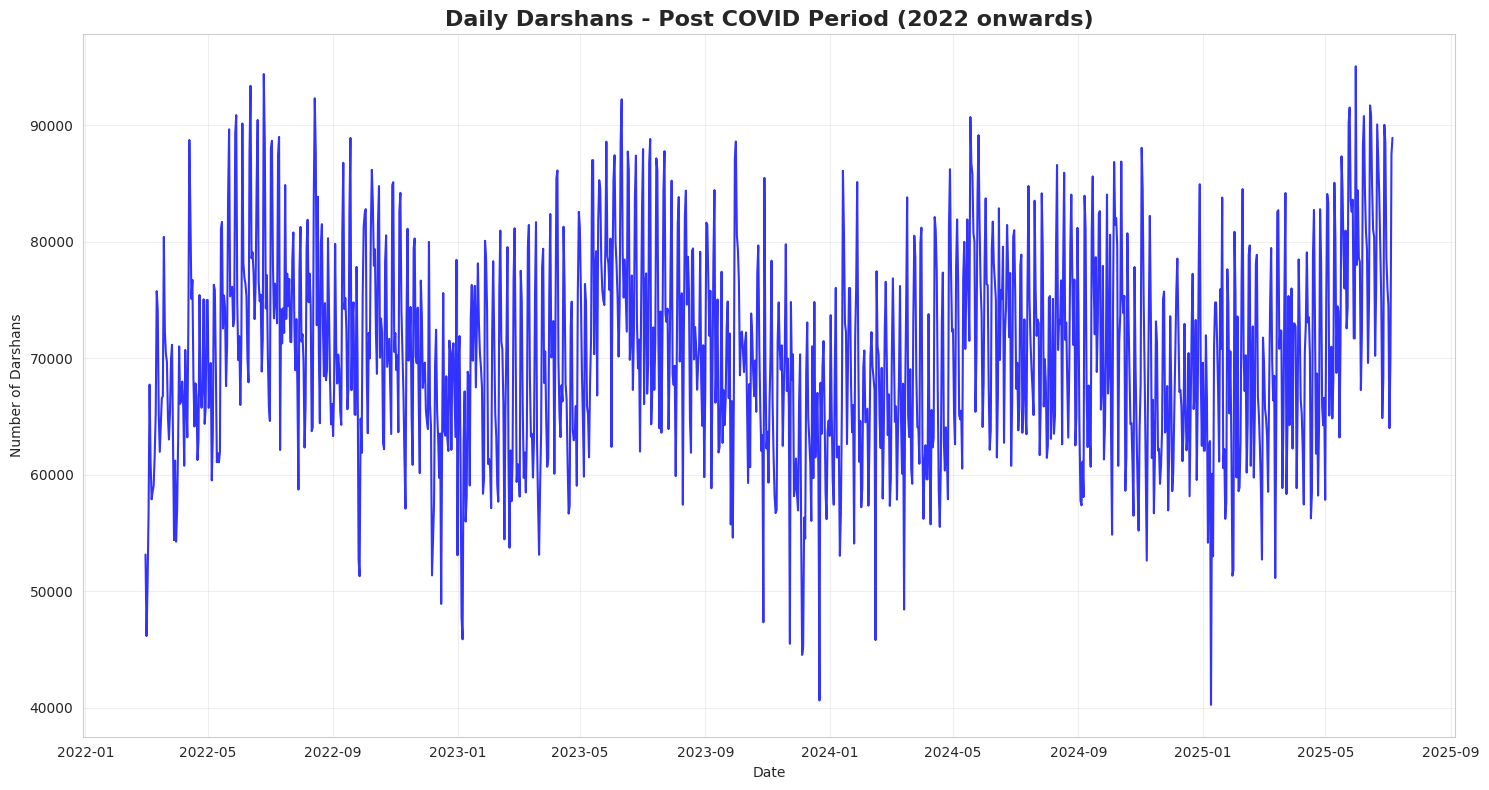

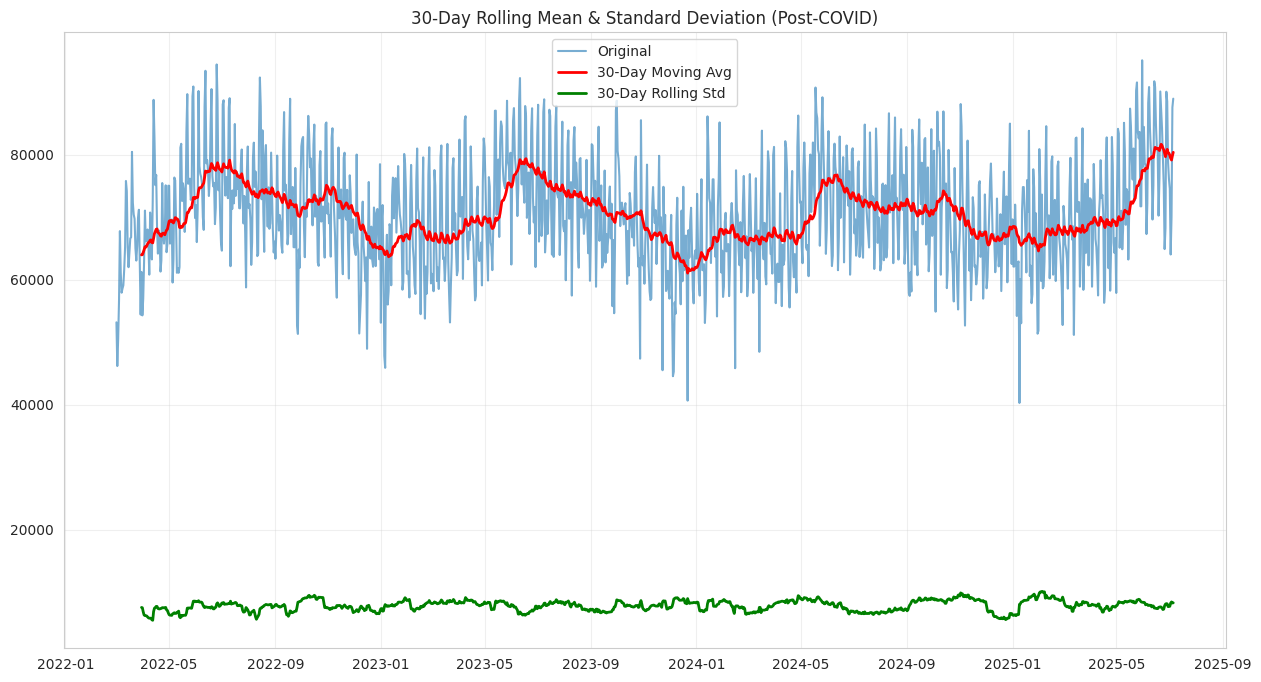

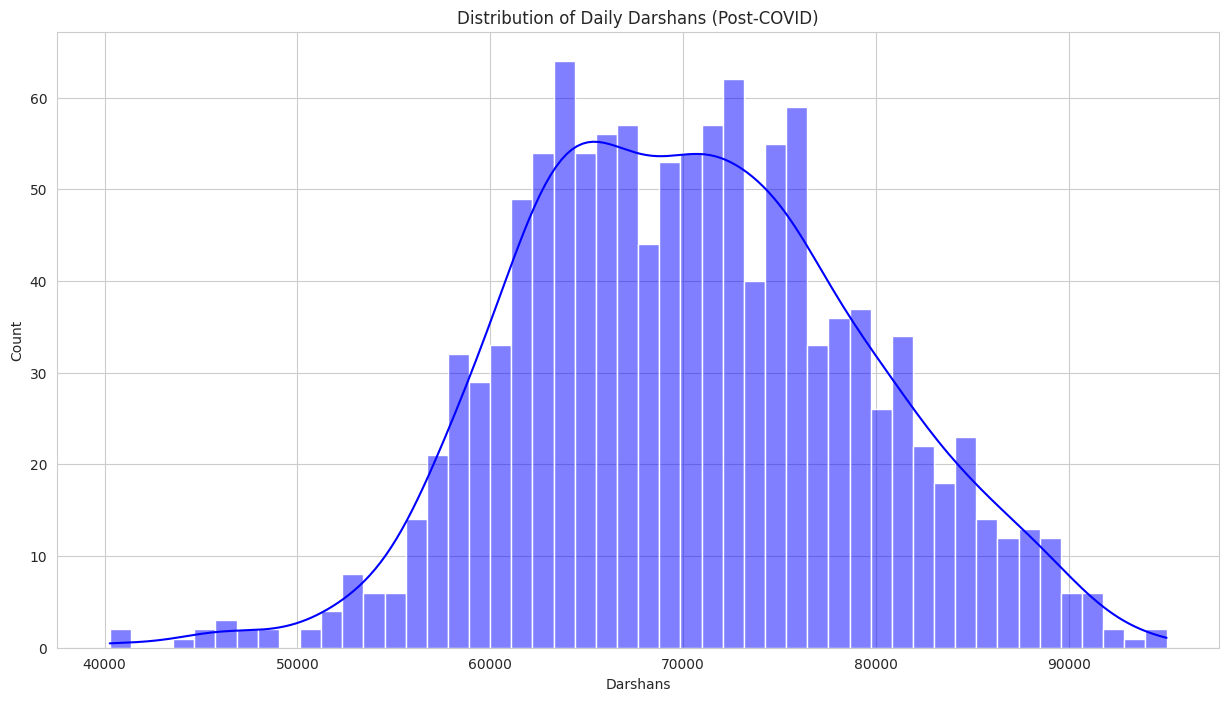

/tmp/ipykernel_1790/3884374395.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, palette="Blues")


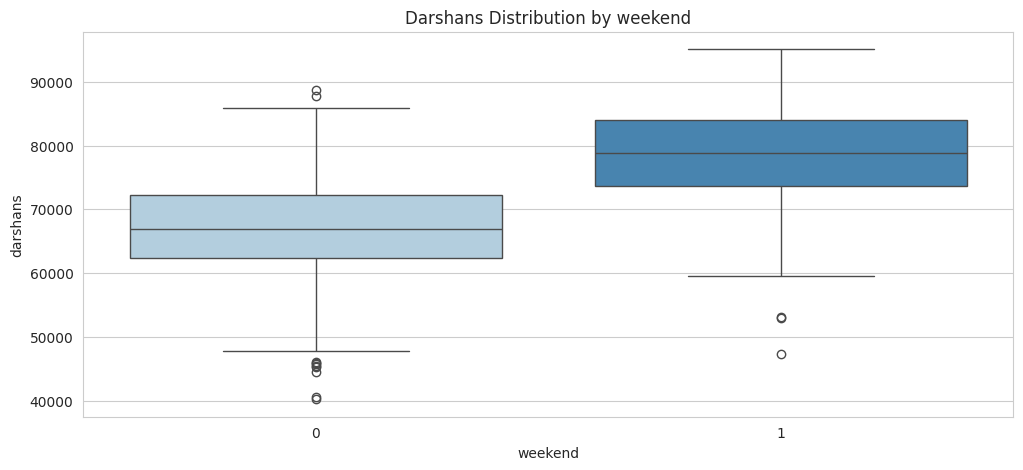

/tmp/ipykernel_1790/3884374395.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, palette="Blues")


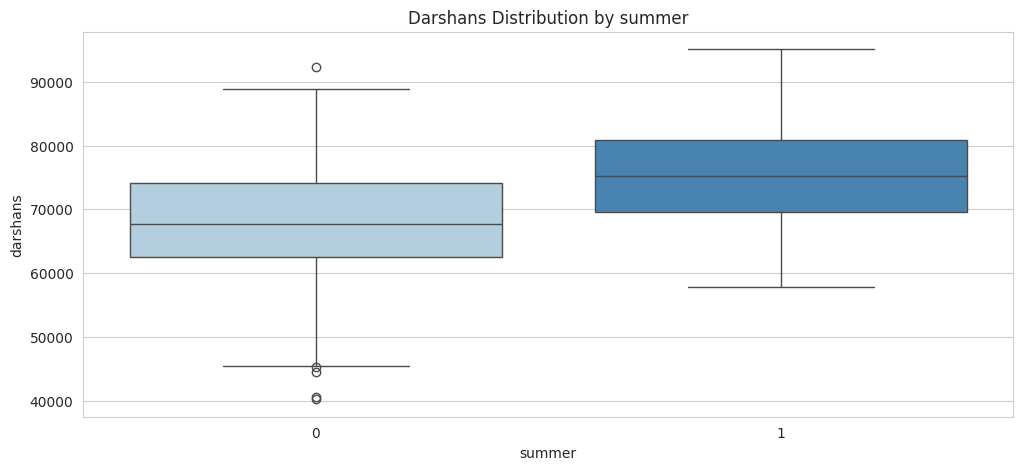

/tmp/ipykernel_1790/3884374395.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, palette="Blues")


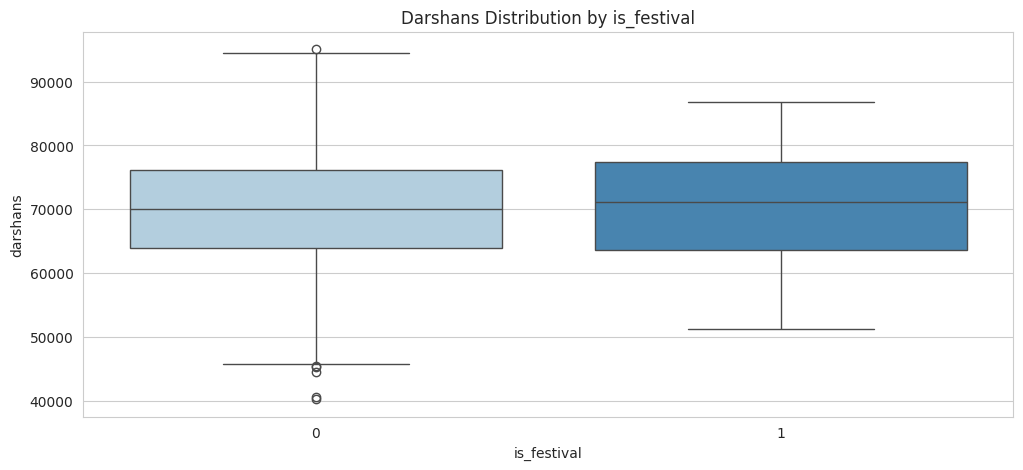

/tmp/ipykernel_1790/3884374395.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, palette="Blues")


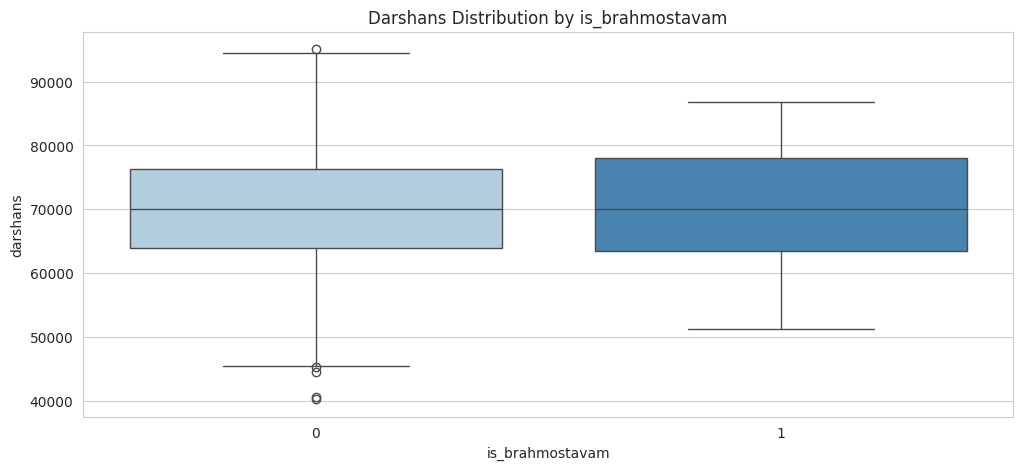

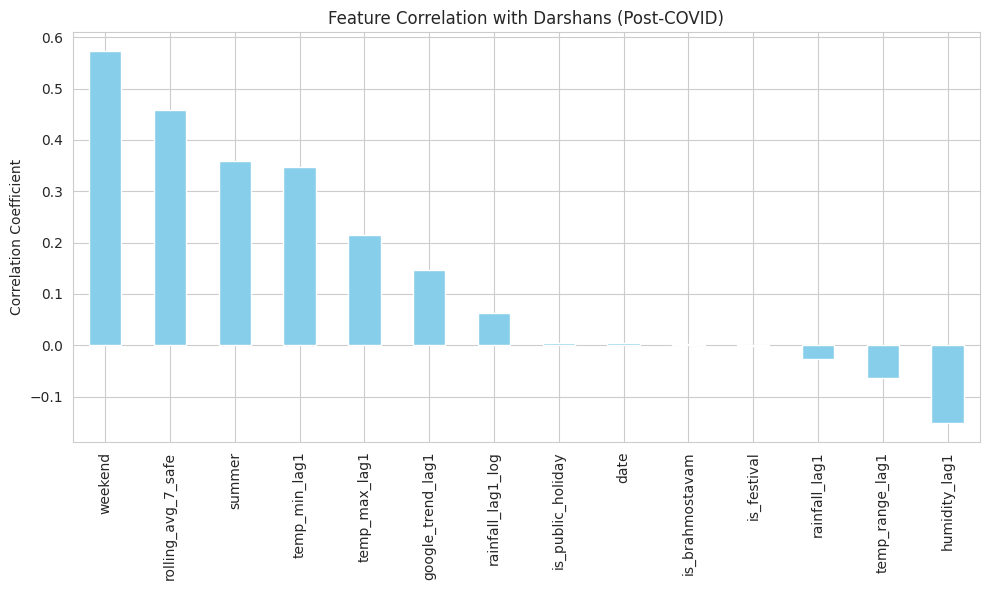

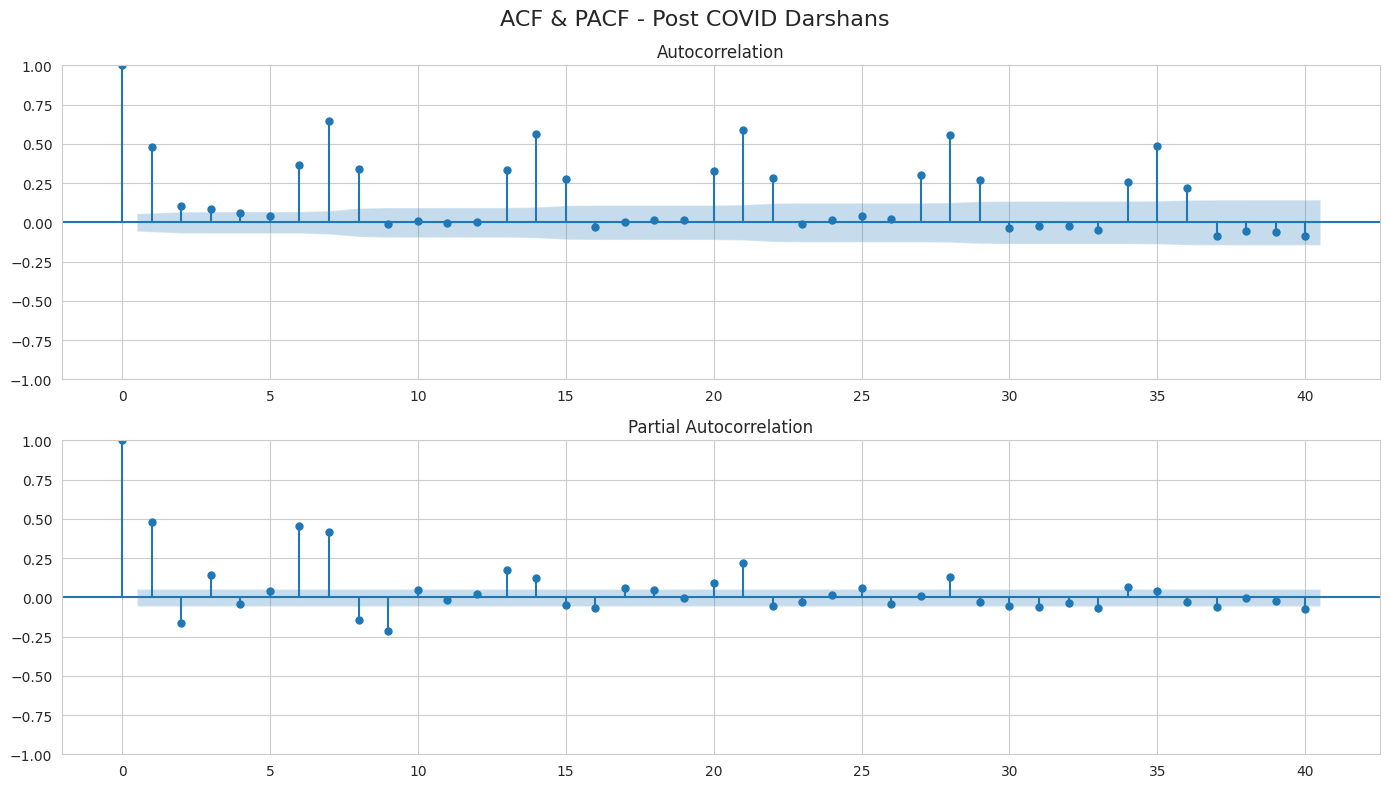


✅ EDA Completed! All plots saved in 'POST_COVID_EDA/' folder


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ====================== SETUP ======================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# Create folders
os.makedirs('POST_COVID_EDA', exist_ok=True)
for folder in ['Time_Series', 'Distributions', 'Categorical', 'Correlation', 'ACF_PACF']:
    os.makedirs(f'POST_COVID_EDA/{folder}', exist_ok=True)

# LOAD DATA
df = pd.read_csv('ttd_darshans_postcovid.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("Post-COVID Data Shape:", df.shape)
print("Date Range:", df['date'].min().date(), "to", df['date'].max().date())
print("\nColumns:", df.columns.tolist())

target = 'darshans'

#  BASIC STATISTICS
print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)
print(df.describe())

# TIME SERIES PLOT
plt.figure()
plt.plot(df['date'], df[target], color='blue', linewidth=1.5, alpha=0.8)
plt.title('Daily Darshans - Post COVID Period (2022 onwards)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Darshans')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('POST_COVID_EDA/Time_Series/01_Daily_Darshans_Post_COVID.png', dpi=300, bbox_inches='tight')
plt.show()

# ROLLING MEAN & STD
plt.figure()
plt.plot(df['date'], df[target], label='Original', alpha=0.6)
plt.plot(df['date'], df[target].rolling(30).mean(), label='30-Day Moving Avg', color='red', linewidth=2)
plt.plot(df['date'], df[target].rolling(30).std(), label='30-Day Rolling Std', color='green', linewidth=2)
plt.title('30-Day Rolling Mean & Standard Deviation (Post-COVID)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('POST_COVID_EDA/Time_Series/02_Rolling_Mean_Std.png', dpi=300, bbox_inches='tight')
plt.show()

# DISTRIBUTION
plt.figure()
sns.histplot(df[target], kde=True, bins=50, color='blue')
plt.title('Distribution of Daily Darshans (Post-COVID)')
plt.xlabel('Darshans')
plt.savefig('POST_COVID_EDA/Distributions/03_Darshans_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# CATEGORICAL ANALYSIS
cat_features = ['weekend', 'summer', 'is_festival', 'is_brahmostavam']

for col in cat_features:
    if col in df.columns:
        plt.figure(figsize=(12, 5))
        sns.boxplot(x=col, y=target, data=df, palette="Blues")
        plt.title(f'Darshans Distribution by {col}')
        plt.savefig(f'POST_COVID_EDA/Categorical/04_Boxplot_{col}.png', dpi=300, bbox_inches='tight')
        plt.show()

# CORRELATION WITH TARGET
plt.figure(figsize=(10, 6))
corr = df.corr()[target].sort_values(ascending=False)
corr.drop(target).plot(kind='bar', color='skyblue')
plt.title('Feature Correlation with Darshans (Post-COVID)')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('POST_COVID_EDA/Correlation/05_Correlation_With_Target.png', dpi=300, bbox_inches='tight')
plt.show()

# ACF-PACF
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df[target], lags=40, ax=axes[0])
plot_pacf(df[target], lags=40, ax=axes[1])
plt.suptitle('ACF & PACF - Post COVID Darshans', fontsize=16)
plt.tight_layout()
plt.savefig('POST_COVID_EDA/ACF_PACF/06_ACF_PACF.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ EDA Completed! All plots saved in 'POST_COVID_EDA/' folder")

# **Stationarity Analysis**
**Check that given series is Stationarity or not with **ADF** and **KPSS** tests and Plot Graphs.**

Post-COVID Data Shape: (1222, 12)
Date Range: 2022-03-01 to 2025-07-06
STATIONARITY TEST ON POST-COVID DATA (Original Series)
=== Augmented Dickey-Fuller Test ===
ADF Statistic     : -2.806679
p-value           : 0.057326
Critical Values:
   1%: -3.4358
   5%: -2.8640
   10%: -2.5681
Not Stationary (Fail to Reject H0)

=== KPSS Test ===
KPSS Statistic    : 0.239999
p-value           : 0.100000
Stationary (Fail to Reject H0)

STATIONARITY TEST AFTER FIRST DIFFERENCING
=== Augmented Dickey-Fuller Test ===
ADF Statistic     : -11.951956
p-value           : 0.000000
Critical Values:
   1%: -3.4358
   5%: -2.8640
   10%: -2.5681
Stationary (Reject H0)

=== KPSS Test ===
KPSS Statistic    : 0.084502
p-value           : 0.100000
Stationary (Fail to Reject H0)


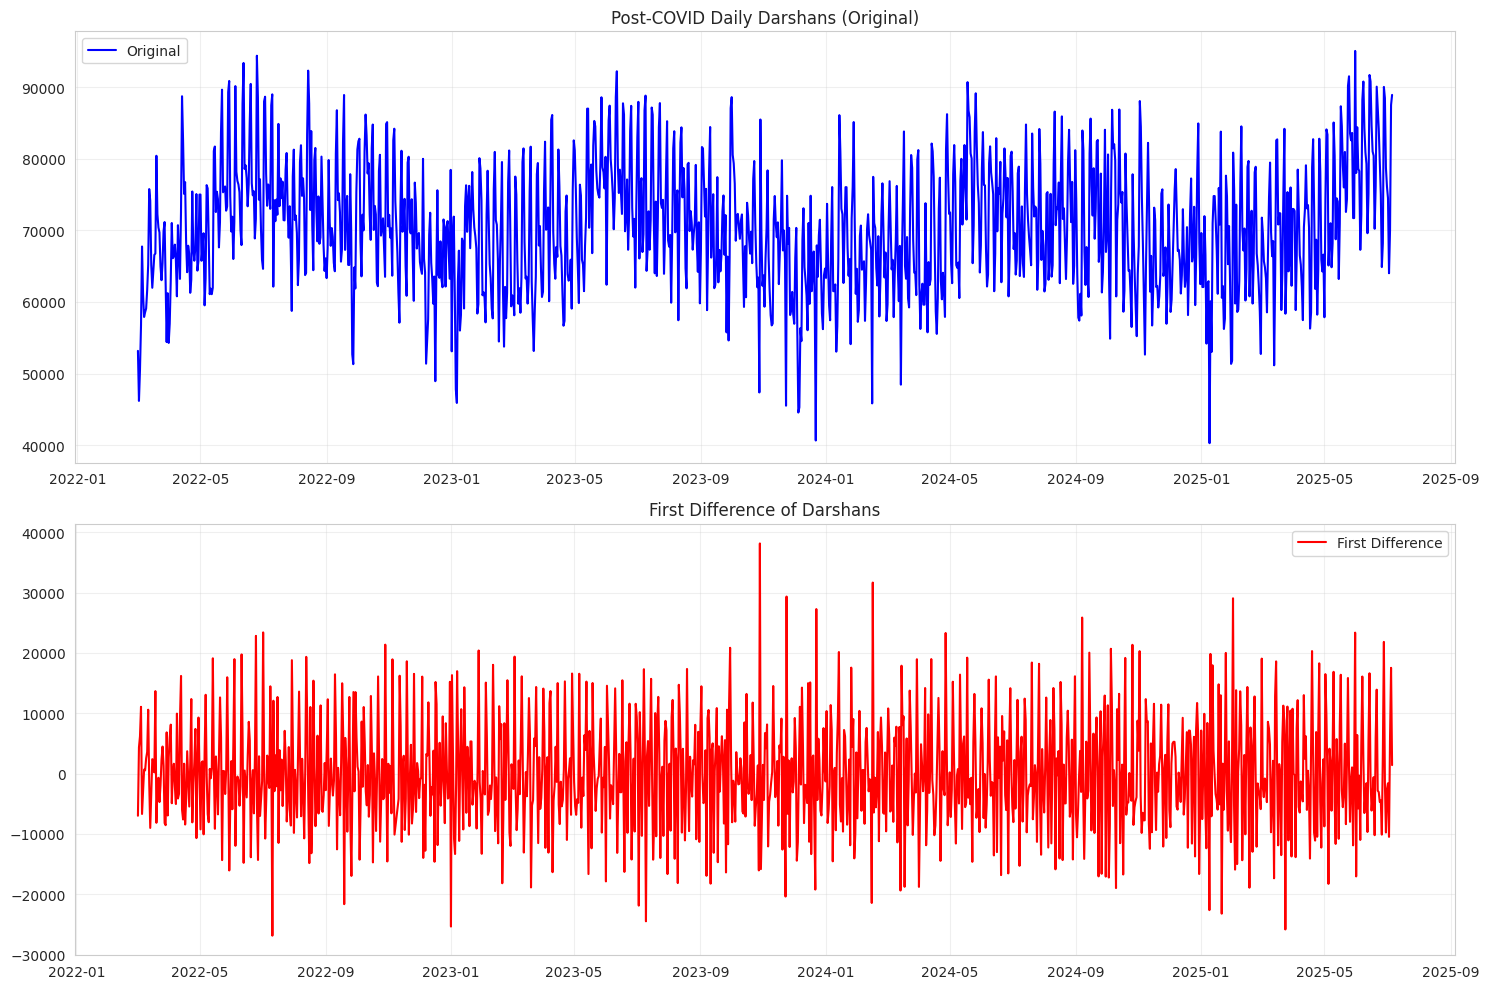

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

# LOAD POST-COVID DATA
df = pd.read_csv('ttd_darshans_postcovid.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target = 'darshans'
print("Post-COVID Data Shape:", df.shape)
print("Date Range:", df['date'].min().date(), "to", df['date'].max().date())

# STATIONARITY TESTS
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(" - - - Augmented Dickey-Fuller Test - - -")
    print(f"ADF Statistic     : {result[0]:.6f}")
    print(f"p-value           : {result[1]:.6f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print(" Stationary (Reject H0)")
    else:
        print(" Not Stationary (Fail to Reject H0)")

def kpss_test(series):
    result = kpss(series, regression='c', nlags='auto')
    print("\n- - - KPSS Test - - -")
    print(f"KPSS Statistic    : {result[0]:.6f}")
    print(f"p-value           : {result[1]:.6f}")
    if result[1] < 0.05:
        print(" Not Stationary (Reject H0)")
    else:
        print(" Stationary (Fail to Reject H0)")

# Run tests on original series
print("="*70)
print("STATIONARITY TEST ON POST-COVID DATA (Original Series)")
print("="*70)
adf_test(df[target])
kpss_test(df[target])

# FIRST DIFFERENCE
print("\n" + "="*70)
print("STATIONARITY TEST AFTER FIRST DIFFERENCING")
print("="*70)
df_diff = df[target].diff().dropna()

adf_test(df_diff)
kpss_test(df_diff)

# Graphss
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Original Series
axes[0].plot(df['date'], df[target], color='blue', label='Original')
axes[0].set_title('Post-COVID Daily Darshans (Original)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# First Difference
axes[1].plot(df['date'][1:], df_diff, color='red', label='First Difference')
axes[1].set_title('First Difference of Darshans')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Saving plotts
os.makedirs('POST_COVID_EDA/Stationarity', exist_ok=True)
plt.tight_layout()
plt.savefig('POST_COVID_EDA/Stationarity/07_Stationarity_Plots.png', dpi=300, bbox_inches='tight')
plt.show()

***ACF and PACF plots***

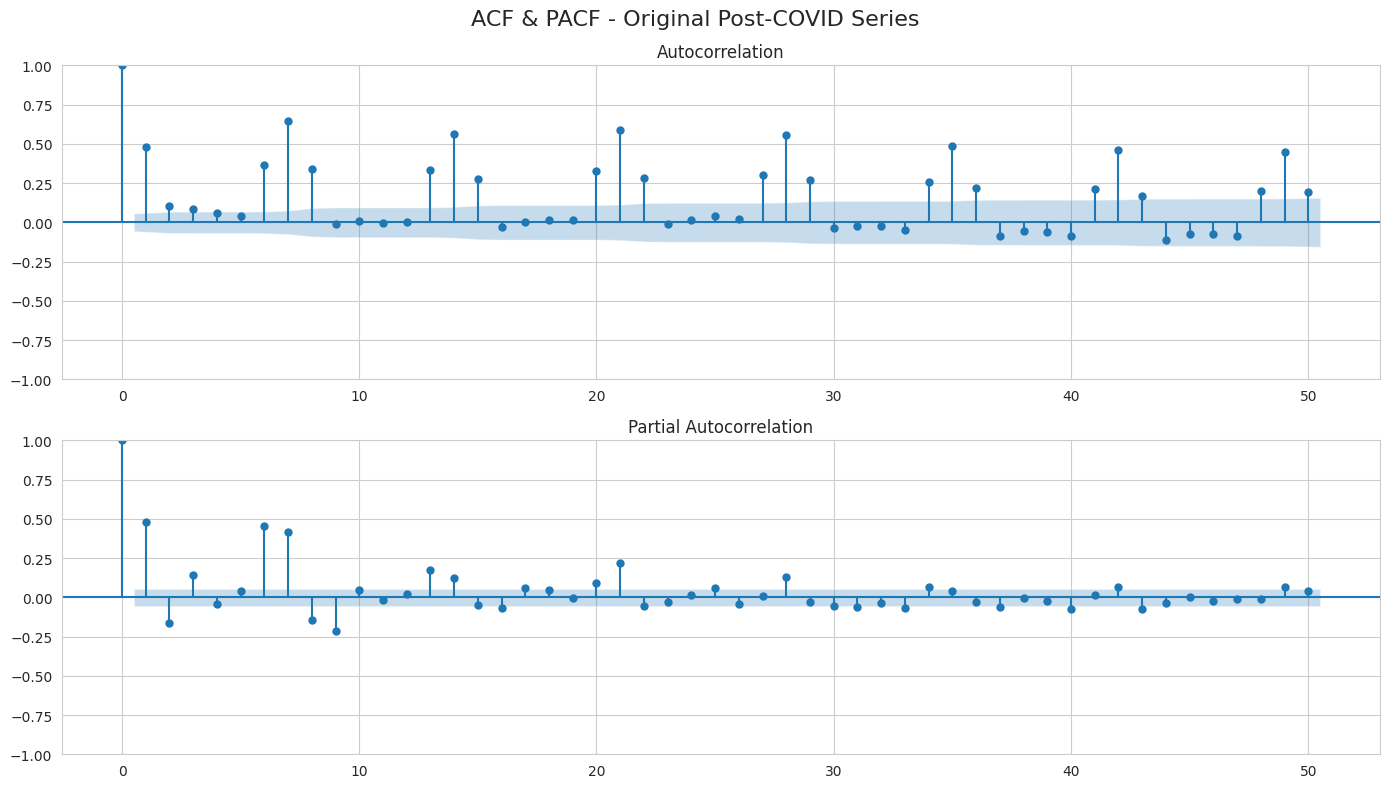

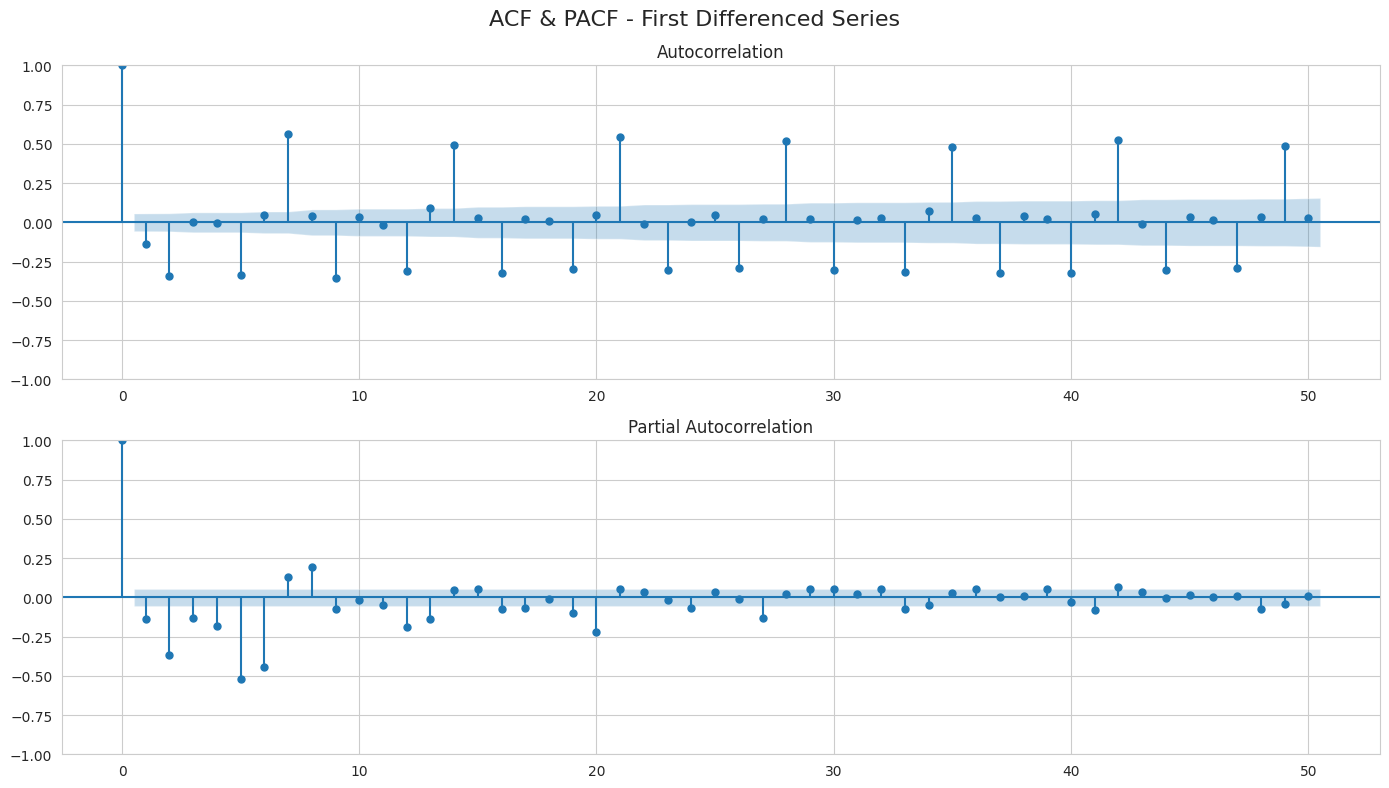

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

# load data
df = pd.read_csv('ttd_darshans_postcovid.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target = 'darshans'

print("Post-COVID Shape:", df.shape)
print("Date Range:", df['date'].min().date(), "to", df['date'].max().date())

# Create folder
os.makedirs('POST_COVID_EDA/ACF_PACF', exist_ok=True)

# ACF & PACF plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. ACF of Original Series
plot_acf(df[target], lags=40, ax=axes[0,0])
axes[0,0].set_title('ACF - Original Post-COVID Series')

# 2. PACF of Original Series
plot_pacf(df[target], lags=40, ax=axes[0,1])
axes[0,1].set_title('PACF - Original Post-COVID Series')

# 3. ACF of First Difference
diff_series = df[target].diff().dropna()
plot_acf(diff_series, lags=40, ax=axes[1,0])
axes[1,0].set_title('ACF - First Differenced Series')

# 4. PACF of First Difference
plot_pacf(diff_series, lags=40, ax=axes[1,1])
axes[1,1].set_title('PACF - First Differenced Series')

plt.tight_layout()
plt.savefig('POST_COVID_EDA/ACF_PACF/08_ACF_PACF_PostCOVID.png', dpi=300, bbox_inches='tight')
plt.show()

# Interpretation
print("\n" + "="*80)
print("ACF / PACF INTERPRETATION GUIDE (Post-COVID Data)")
print("="*80)
print("""
• Strong spikes at lag 7 → Weekly seasonality (very clear in pilgrim data)
• Spikes at lag 1, 2, 3 → Short-term dependence
• If PACF cuts off after lag p → AR(p) order
• If ACF cuts off after lag q → MA(q) order
• Seasonal patterns at lag 7, 14, 21, 28 → Seasonal (P,D,Q,7)
""")

**SPLIT DATA ON TRAIN - VALIDATION - TEST**

Total Rows: 1222
Date Range: 2022-03-01 to 2025-07-06

FINAL SPLIT SUMMARY
Train Shape      : (1130, 12) | 2022-03-01 → 2025-04-05
Validation Shape : (61, 12)   | 2025-04-06 → 2025-06-05
Test Shape       : (31, 12)  | 2025-06-06 → 2025-07-06
Total            : 1222 days


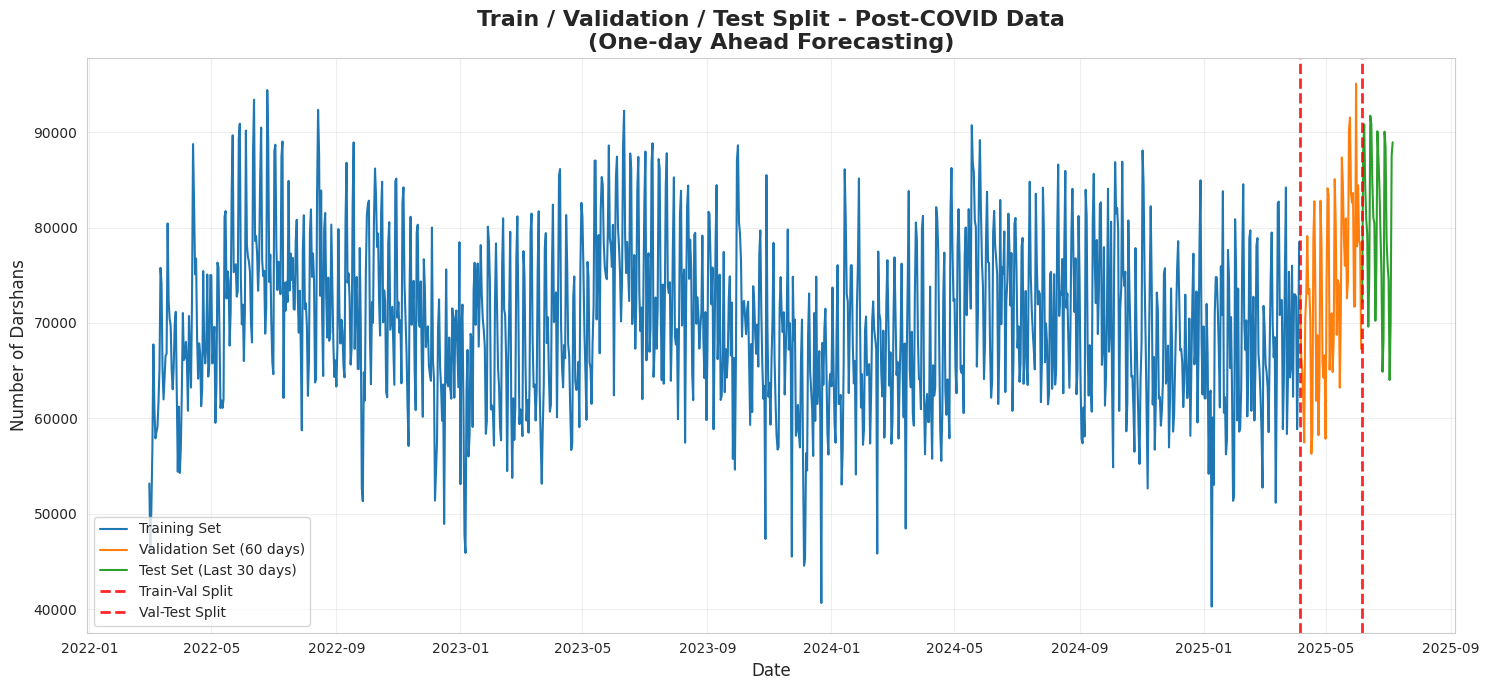

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# load data
df = pd.read_csv('ttd_darshans_postcovid.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("Total Rows:", df.shape[0])
print("Date Range:", df['date'].min().date(), "to", df['date'].max().date())

#split data
latest_date = df['date'].max()

# Test: Last 30 days
test = df[df['date'] >= latest_date - timedelta(days=30)].copy()

# Validation: Previous 60 days
val_end = test['date'].min() - timedelta(days=1)
val_start = val_end - timedelta(days=60)
val = df[(df['date'] >= val_start) & (df['date'] <= val_end)].copy()

# Train: Everything before Validation
train = df[df['date'] < val_start].copy()

# Summary
print("\n" + "="*65)
print("FINAL SPLIT SUMMARY")
print("="*65)
print(f"Train Shape      : {train.shape} | {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Validation Shape : {val.shape}   | {val['date'].min().date()} → {val['date'].max().date()}")
print(f"Test Shape       : {test.shape}  | {test['date'].min().date()} → {test['date'].max().date()}")
print(f"Total            : {len(train) + len(val) + len(test)} days")

# Train - Validation - Test Split
plt.figure(figsize=(15, 7))

plt.plot(train['date'], train['darshans'], label='Training Set', color='#1f77b4', linewidth=1.5)
plt.plot(val['date'], val['darshans'], label='Validation Set (60 days)', color='#ff7f0e', linewidth=1.5)
plt.plot(test['date'], test['darshans'], label='Test Set (Last 30 days)', color='#2ca02c', linewidth=1.5)

plt.title('Train / Validation / Test Split - Post-COVID Data\n(One-day Ahead Forecasting)',
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Darshans', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.axvline(x=val['date'].min(), color='red', linestyle='--', alpha=0.85, linewidth=2, label='Train-Val Split')
plt.axvline(x=test['date'].min(), color='red', linestyle='--', alpha=0.85, linewidth=2, label='Val-Test Split')

plt.legend()
plt.tight_layout()
plt.show()

# **Installing PMDARIMA Library**

**The `pmdarima` library is used to automatically determine the optimal values of:**
- **p, d, q** for ARIMA
- **P, D, Q** for SARIMA

**Using the `auto_arima()` function. This helps in selecting the best forecasting model parameters automatically.**



In [ ]:
!pip install pmdarima

***FIND BEST VALUE OF HYPER-PARAMETER WITH AIC***

In [ ]:
import pandas as pd
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('ttd_darshans_postcovid.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target = 'darshans'

# Exogenous variables
exog_cols = [col for col in df.columns if col not in ['date', target]]
exog = df[exog_cols]

print("Shape:", df.shape)
print(f"Exogenous Features: {len(exog_cols)}")

# Hyper-Parameter Search
print("\n" + "="*90)
print("AUTO_ARIMA HYPERPARAMETER TUNING")
print("="*90)

best_model = None
best_aic = float('inf')
results = []

for d in [0, 1]:
    for D in [0, 1]:
        print(f"\n→ Testing d={d}, D={D} ...")

        model = auto_arima(
            df[target],
            exogenous=exog,
            start_p=0, max_p=7,
            start_q=0, max_q=5,
            d=d,
            seasonal=True,
            m=7,
            start_P=0, max_P=3,
            start_Q=0, max_Q=3,
            D=D,
            stepwise=True,
            trace=True,
            error_action='ignore',
            suppress_warnings=True,
            maxiter=50,
            n_fits=30
        )

        aic = model.aic()
        results.append({
            'd': d,
            'D': D,
            'order': model.order,
            'seasonal_order': model.seasonal_order,
            'aic': aic
        })

        print(f"   AIC: {aic:.2f} | Order: {model.order}{model.seasonal_order}")

        if aic < best_aic:
            best_aic = aic
            best_model = model

# Summary
print("\n" + "="*90)
print("ALL TESTED COMBINATIONS")
print("="*90)
for r in sorted(results, key=lambda x: x['aic']):
    print(f"d={r['d']}, D={r['D']} | Order: {r['order']}{r['seasonal_order']} | AIC: {r['aic']:.2f}")

print("\n" + "="*90)
print("BEST MODEL")
print("="*90)
print(f"Best d          : {best_model.order[1]}")
print(f"Best D          : {best_model.seasonal_order[1]}")
print(f"Best Order      : {best_model.order}")
print(f"Best Seasonal   : {best_model.seasonal_order}")
print(f"Best AIC        : {best_model.aic():.2f}")

print("\n Hyperparameter tuning completed!")

**AR(7) - MODEL**

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

target = 'darshans'
best_p = 7

print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

# Rolling Forecast Function
def rolling_ar_forecast(train_series, test_series, lags):
    history = train_series.copy()
    predictions = []

    for t in range(len(test_series)):
        # Refit model at each step
        model = AutoReg(history, lags=lags, old_names=False).fit()

        # Predict next step
        pred = model.predict(start=len(history), end=len(history)).iloc[0]
        predictions.append(pred)

        # Add ACTUAL value to history
        new_value = test_series.iloc[t]
        history = pd.concat([history, pd.Series([new_value], index=[test_series.index[t]])])

    return np.array(predictions)


# Validation
print("\nRunning Rolling Forecast on Validation...")
val_pred = rolling_ar_forecast(train[target], val[target], best_p)

# test
print("Running Rolling Forecast on Test...")
train_val_series = pd.concat([train[target], val[target]])
test_pred = rolling_ar_forecast(train_val_series, test[target], best_p)


# metrix print
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{name:12} → MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | MAPE: {mape:6.2f}%")


print("\n" + "="*70)
print(f"AR({best_p}) MODEL - ROLLING FORECAST PERFORMANCE")
print("="*70)

evaluate(val[target], val_pred, "Validation")
evaluate(test[target], test_pred, "Test")


# plot
plt.figure(figsize=(15, 7))

plt.plot(test['date'], test[target], label='Actual', linewidth=2)
plt.plot(test['date'], test_pred, linestyle='--', linewidth=2, label=f'AR({best_p}) Rolling Forecast')

plt.title(f'AR({best_p}) - Realistic One-Step Ahead Forecast (Test Set)')
plt.xlabel('Date')
plt.ylabel('Number of Darshans')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**MA(6) - Model**

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

target = 'darshans'
best_q = 6   # from auto_arima result

print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

# Rolling MA function
def rolling_ma_forecast(train_series, test_series, q):
    history = train_series.copy()
    predictions = []

    for t in range(len(test_series)):
        # Refit MA(q) model each step
        model = ARIMA(history, order=(0, 0, q))
        model_fit = model.fit()

        # Predict next step
        pred = model_fit.forecast(steps=1).iloc[0]
        predictions.append(pred)

        # Add ACTUAL value to history
        new_value = test_series.iloc[t]
        history = pd.concat([history, pd.Series([new_value])], ignore_index=True)

    return np.array(predictions)


# Run
print("\nRunning Rolling MA Forecast on Validation...")
val_pred = rolling_ma_forecast(train[target], val[target], best_q)

print("Running Rolling MA Forecast on Test...")
train_val_series = pd.concat([train[target], val[target]], ignore_index=True)
test_pred = rolling_ma_forecast(train_val_series, test[target], best_q)


# Metrix
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:12} → MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | MAPE: {mape:6.2f}%")

print("\n" + "="*70)
print(f"MA({best_q}) MODEL - ROLLING FORECAST PERFORMANCE")
print("="*70)
evaluate(val[target], val_pred, "Validation")
evaluate(test[target], test_pred, "Test")


# PLot
plt.figure(figsize=(15, 7))
plt.plot(test['date'], test[target], label='Actual', linewidth=2, color='black')
plt.plot(test['date'], test_pred, linestyle='--', linewidth=2,
         label=f'MA({best_q}) Rolling Forecast', color='red')
plt.title(f'MA({best_q}) - One-Step Ahead Rolling Forecast (Test Set)')
plt.xlabel('Date')
plt.ylabel('Number of Darshans')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**ARIMA MODEL (7,0,6)**



In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Parameter
target = 'darshans'
p = 7
q = 6

print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

# Rolling ARIMA Function
def rolling_arma_forecast(train_series, test_series, p, q):
    history = train_series.copy()
    predictions = []

    for t in range(len(test_series)):
        # Fit ARMA model
        model = ARIMA(history, order=(p, 1, q))
        model_fit = model.fit()

        pred = model_fit.forecast(steps=1).iloc[0]
        predictions.append(pred)

        # Append actual value
        actual_value = test_series.iloc[t]
        history = pd.concat([
            history,
            pd.Series([actual_value], index=[test_series.index[t]])
        ])

    return np.array(predictions)


# Validation
print("\nRunning Rolling ARMA Forecast on Validation...")
val_pred = rolling_arma_forecast(train[target], val[target], p, q)

# Test
print("Running Rolling ARMA Forecast on Test...")
train_val_series = pd.concat([train[target], val[target]])
test_pred = rolling_arma_forecast(train_val_series, test[target], p, q)


# Metrix
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"{name:12} → MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | MAPE: {mape:6.2f}%")


print("\n" + "="*70)
print(f"ARMA({p},{q}) MODEL - ROLLING FORECAST PERFORMANCE")
print("="*70)

evaluate(val[target], val_pred, "Validation")
evaluate(test[target], test_pred, "Test")


# graphsss
plt.figure(figsize=(15, 7))

plt.plot(test['date'], test[target], label='Actual', linewidth=2)
plt.plot(test['date'], test_pred, linestyle='--', linewidth=2,
         label=f'ARMA({p},{q}) Rolling Forecast')

plt.title(f'ARMA({p},{q}) - One-Step Ahead Forecast (Realistic)')
plt.xlabel('Date')
plt.ylabel('Number of Darshans')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**ARIMAX(7,0,6)**

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

target = 'darshans'

# Use features EXCEPT date, target, and the lag features you want to remove
feature_cols = [col for col in train.columns
                if col not in ['date', target,'rainfall_lag1','temp_min_lag1','is_public_holiday']]

print("Using features:", feature_cols)
print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

# Rolling Forecast function
def rolling_arimax(train_df, test_df, p, d, q):
    history_y = train_df[target].copy()
    history_exog = train_df[feature_cols].copy()
    predictions = []

    for t in range(len(test_df)):
        model = ARIMA(
            history_y,
            exog=history_exog,
            order=(p, d, q)
        )
        model_fit = model.fit()

        next_exog = test_df[feature_cols].iloc[t:t+1]
        pred = model_fit.forecast(steps=1, exog=next_exog).iloc[0]
        predictions.append(pred)

        # Append ACTUAL value
        actual_value = test_df[target].iloc[t]
        history_y = pd.concat([history_y, pd.Series([actual_value])], ignore_index=True)
        history_exog = pd.concat([history_exog, next_exog], ignore_index=True)

    return np.array(predictions)


parameter
p, d, q = 7, 0, 6

# validation
print("\nRunning ARIMAX Rolling Forecast on Validation...")
val_pred = rolling_arimax(train, val, p, d, q)

# test
print("Running ARIMAX Rolling Forecast on Test...")
train_val = pd.concat([train, val], ignore_index=True)
test_pred = rolling_arimax(train_val, test, p, d, q)


# metrix
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print(f"{name:12} → MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | MAPE: {mape:6.2f}%")

print("\n" + "="*70)
print(f"ARIMAX({p},{d},{q}) MODEL - ROLLING ONE-STEP AHEAD PERFORMANCE")
print("="*70)

evaluate(val[target], val_pred, "Validation")
evaluate(test[target], test_pred, "Test")


# Graph
plt.figure(figsize=(15, 7))
plt.plot(test['date'], test[target], label='Actual', linewidth=2, color='black')
plt.plot(test['date'], test_pred, linestyle='--', linewidth=2,
         label=f'ARIMAX({p},{d},{q}) Rolling Forecast', color='red')

plt.title(f'ARIMAX({p},{d},{q}) - One-Step Ahead Rolling Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Darshans')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**SARIMAX(6,0,6)**

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

target = 'darshans'

# Use ALL features except date and targ
feature_cols = [col for col in train.columns
                if col not in ['date', target,'rainfall_lag1','temp_min_lag1','is_public_holiday']]

print("Using features:", feature_cols)
print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

# Rolling SARIMAX Function
def rolling_sarimax(train_df, test_df, order, seasonal_order):
    history_y = train_df[target].copy()
    history_exog = train_df[feature_cols].copy()

    predictions = []

    for t in range(len(test_df)):
        # Fit SARIMAX
        model = SARIMAX(
            history_y,
            exog=history_exog,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        model_fit = model.fit(disp=False)

        # Next step exog
        next_exog = test_df[feature_cols].iloc[t:t+1]

        # Forecast
        pred = model_fit.forecast(steps=1, exog=next_exog).iloc[0]
        predictions.append(pred)

        # Append actual
        history_y = pd.concat([
            history_y,
            pd.Series([test_df[target].iloc[t]], index=[test_df.index[t]])
        ])

        # Append exog
        history_exog = pd.concat([
            history_exog,
            next_exog
        ])

    return np.array(predictions)


# Paramter
order = (6, 0, 6)
seasonal_order = (1, 1, 1, 7)

# Validation
print("\nRunning SARIMAX on Validation...")
val_pred = rolling_sarimax(train, val, order, seasonal_order)

# Test
print("Running SARIMAX on Test...")
train_val = pd.concat([train, val])
test_pred = rolling_sarimax(train_val, test, order, seasonal_order)


# Metrix
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"{name:12} → MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | MAPE: {mape:6.2f}%")


print("\n" + "="*70)
print("SARIMAX MODEL PERFORMANCE")
print("="*70)

evaluate(val[target], val_pred, "Validation")
evaluate(test[target], test_pred, "Test")


# Plot
plt.figure(figsize=(15, 7))

plt.plot(test['date'], test[target], label='Actual', linewidth=2)
plt.plot(test['date'], test_pred, linestyle='--', linewidth=2,
         label='SARIMAX Forecast')

plt.title('SARIMAX - Rolling One-Step Ahead Forecast')
plt.xlabel('Date')
plt.ylabel('Darshans')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**DEEP LEARNING MODEL - *LSTM***

Train: (1130, 14), Val: (61, 14), Test: (31, 14)

Training LSTM...
Epoch 1/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.8743 - val_loss: 0.8705
Epoch 2/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.8133 - val_loss: 0.8340
Epoch 3/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.7558 - val_loss: 0.6389
Epoch 4/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.6560 - val_loss: 0.5494
Epoch 5/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5847 - val_loss: 0.5763
Epoch 6/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5375 - val_loss: 0.7167
Epoch 7/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4729 - val_loss: 0.5489
Epoch 8/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.4699 - val_loss: 0.5138
Epoch 9/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.4378 - val_loss: 0.4301
Epoch 10/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.4170 - val_loss: 0.7008
Epoch 11/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3969 - val_loss: 0.4

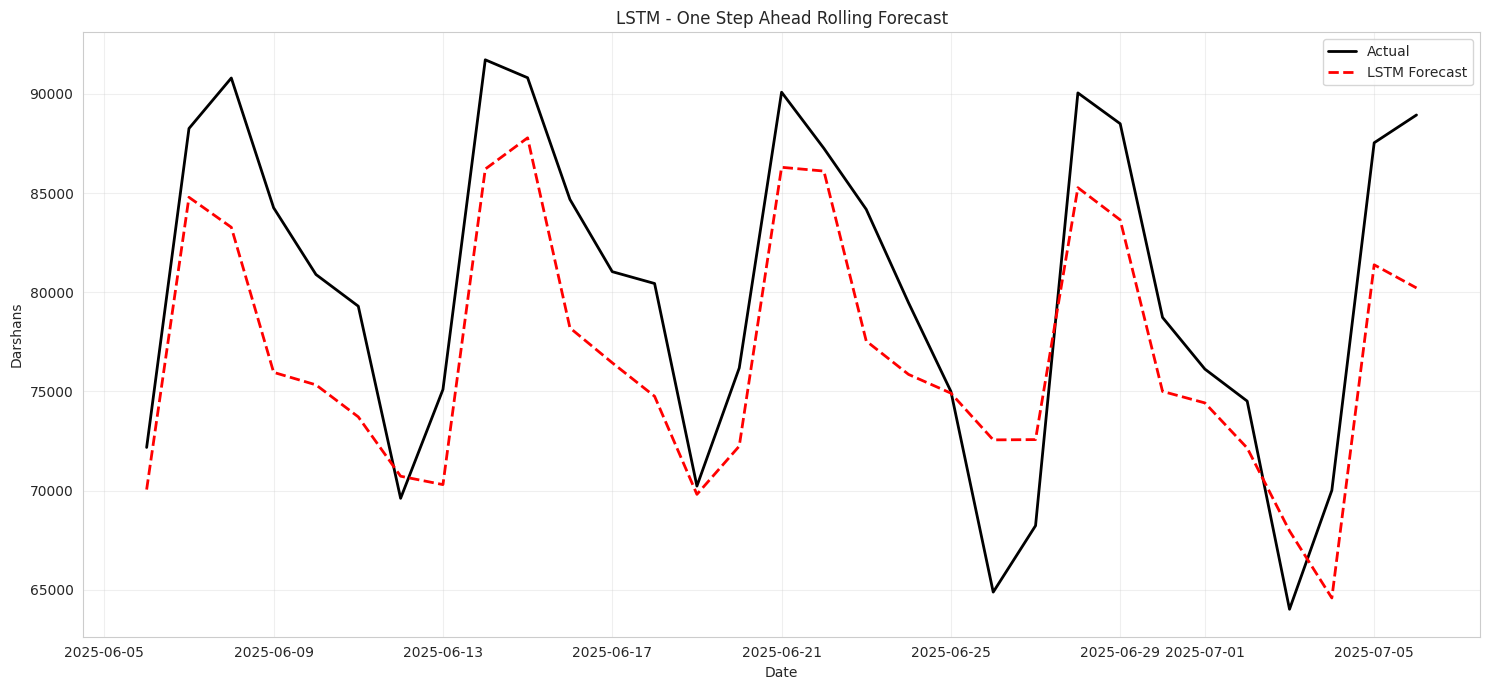

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from datetime import timedelta

# Load data
df = pd.read_csv('ttd_darshans_postcovid.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Split data
latest_date = df['date'].max()

test = df[df['date'] >= latest_date - timedelta(days=30)].copy()

val_end = test['date'].min() - timedelta(days=1)
val_start = val_end - timedelta(days=60)
val = df[(df['date'] >= val_start) & (df['date'] <= val_end)].copy()

train = df[df['date'] < val_start].copy()

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")

# Feature's
target = 'darshans'
feature_cols = [col for col in df.columns if col not in ['date', target]]

# Scalling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(train[feature_cols])
y_train = scaler_y.fit_transform(train[[target]])

X_val = scaler_X.transform(val[feature_cols])
y_val = scaler_y.transform(val[[target]])

X_test = scaler_X.transform(test[feature_cols])
y_test = scaler_y.transform(test[[target]])

# SEQUENCE FUNCTION
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(window_size, len(X)):
        Xs.append(X[i-window_size:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

window_size = 14

X_train_seq, y_train_seq = create_sequences(X_train, y_train, window_size)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, window_size)

# Model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, len(feature_cols))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

# Train
print("\nTraining LSTM...")
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=80,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# Rolling Forecast
def rolling_forecast(model, history_X, future_X, window_size):
    preds = []
    history_X = list(history_X)

    for i in range(len(future_X)):
        X_input = np.array(history_X[-window_size:]).reshape(1, window_size, -1)
        pred = model.predict(X_input, verbose=0)[0][0]
        preds.append(pred)

        # use ACTUAL next observation
        history_X.append(future_X[i])

    return np.array(preds)

# Validation Forecast
print("\nRunning Rolling Forecast on Validation...")

val_pred_scaled = rolling_forecast(
    model,
    X_train,
    X_val,
    window_size
)

val_pred = scaler_y.inverse_transform(val_pred_scaled.reshape(-1, 1)).flatten()
actual_val = val[target].values

# Validation Metrix
val_mae = mean_absolute_error(actual_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(actual_val, val_pred))
val_mape = np.mean(np.abs((actual_val - val_pred) / actual_val)) * 100

print("\n" + "="*70)
print("VALIDATION METRICS")
print("="*70)
print(f"MAE  : {val_mae:.2f}")
print(f"RMSE : {val_rmse:.2f}")
print(f"MAPE : {val_mape:.2f}%")

# Test Forecast
print("\nRunning Rolling Forecast on Test...")

full_X = np.vstack([X_train, X_val])

test_pred_scaled = rolling_forecast(
    model,
    full_X,
    X_test,
    window_size
)

test_pred = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()
actual_test = test[target].values

# Test Metrix
test_mae = mean_absolute_error(actual_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(actual_test, test_pred))
test_mape = np.mean(np.abs((actual_test - test_pred) / actual_test)) * 100

print("\n" + "="*70)
print("TEST METRICS")
print("="*70)
print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"MAPE : {test_mape:.2f}%")

# Grahsss
plt.figure(figsize=(15, 7))

plt.plot(test['date'], actual_test, label='Actual', color='black', linewidth=2)
plt.plot(test['date'], test_pred, label='LSTM Forecast', color='red', linestyle='--', linewidth=2)

plt.title('LSTM - One Step Ahead Rolling Forecast')
plt.xlabel('Date')
plt.ylabel('Darshans')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# LightGBM Hyperparameters

The following hyperparameters are used in the LightGBM model:

- `n_estimators = 1200` → Number of boosting trees
- `learning_rate = 0.03` → Step size for learning
- `max_depth = -1` → No limit on tree depth
- `num_leaves = 64` → Maximum leaves in one tree
- `min_child_samples = 20` → Minimum samples required in a leaf
- `subsample = 0.9` → Fraction of data used per iteration
- `colsample_bytree = 0.9` → Fraction of features used per tree
- `reg_alpha = 0.1` → L1 regularization
- `reg_lambda = 0.1` → L2 regularization
- `random_state = 42` → Ensures reproducibility

Train: (1130, 14), Val: (61, 14), Test: (31, 14)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1363
[LightGBM] [Info] Number of data points in the train set: 1130, number of used features: 12
[LightGBM] [Info] Start training from score 69974.539823
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

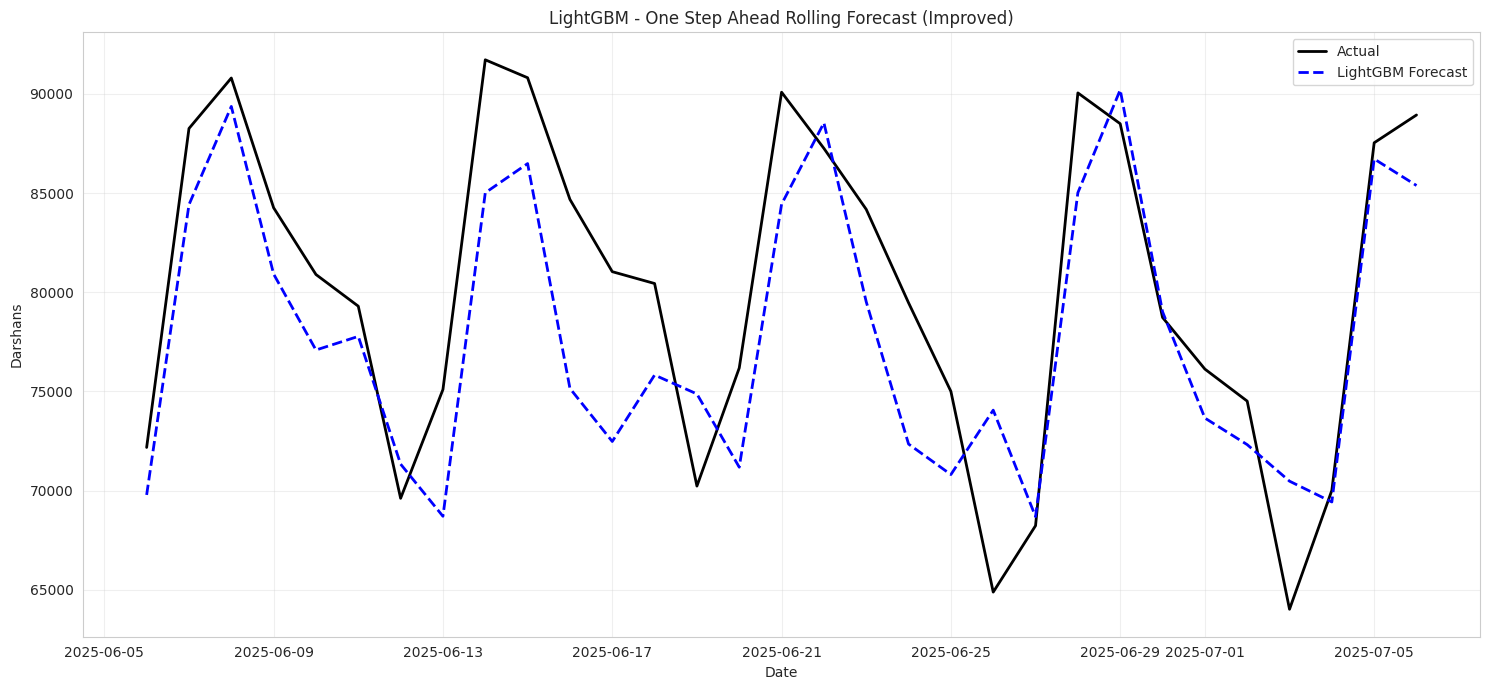

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor

# load data
df = pd.read_csv('ttd_darshans_postcovid.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)


# Split
latest_date = df['date'].max()

test = df[df['date'] >= latest_date - timedelta(days=30)].copy()

val_end = test['date'].min() - timedelta(days=1)
val_start = val_end - timedelta(days=60)
val = df[(df['date'] >= val_start) & (df['date'] <= val_end)].copy()

train = df[df['date'] < val_start].copy()

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")

# Features
target = 'darshans'
feature_cols = [col for col in df.columns if col not in ['date', target]]

# Model
model = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

# ====================== TRAIN ======================
model.fit(train[feature_cols], train[target])

# DYNAMIC ROLLING FORECAST
def rolling_forecast_dynamic(model, history_df, future_df, feature_cols):
    history = history_df.copy()
    preds = []

    for i in range(len(future_df)):
        current = future_df.iloc[i].copy()

        # DYNAMIC FEATURE UPDATE
        if len(history) >= 7:
            current['darshans_lag1'] = history['darshans'].iloc[-1]
            current['darshans_lag7'] = history['darshans'].iloc[-7]
            current['rolling_avg_7_safe'] = history['darshans'].iloc[-7:].mean()

        # Predict
        X_input = current[feature_cols].values.reshape(1, -1)
        pred = model.predict(X_input)[0]
        preds.append(pred)

        # Use Actual Value
        current['darshans'] = future_df.iloc[i]['darshans']

        history = pd.concat([history, pd.DataFrame([current])], ignore_index=True)

    return np.array(preds)

# Validation
print("\nRunning Validation Forecast...")

val_pred = rolling_forecast_dynamic(
    model,
    train,
    val,
    feature_cols
)

actual_val = val[target].values

val_mae = mean_absolute_error(actual_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(actual_val, val_pred))
val_mape = np.mean(np.abs((actual_val - val_pred) / actual_val)) * 100

print("\n" + "="*70)
print("VALIDATION METRICS (LightGBM)")
print("="*70)
print(f"MAE  : {val_mae:.2f}")
print(f"RMSE : {val_rmse:.2f}")
print(f"MAPE : {val_mape:.2f}%")

# Test
print("\nRunning Test Forecast...")

full_df = pd.concat([train, val]).reset_index(drop=True)

test_pred = rolling_forecast_dynamic(
    model,
    full_df,
    test,
    feature_cols
)

actual_test = test[target].values

test_mae = mean_absolute_error(actual_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(actual_test, test_pred))
test_mape = np.mean(np.abs((actual_test - test_pred) / actual_test)) * 100

print("\n" + "="*70)
print("TEST METRICS (LightGBM)")
print("="*70)
print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"MAPE : {test_mape:.2f}%")

# FEATURE IMPORTANCE
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop Features:")
print(importance.head(10))

# Graphh
plt.figure(figsize=(15, 7))

plt.plot(test['date'], actual_test, label='Actual', color='black', linewidth=2)
plt.plot(test['date'], test_pred, label='LightGBM Forecast', color='blue', linestyle='--', linewidth=2)

plt.title('LightGBM - One Step Ahead Rolling Forecast (Improved)')
plt.xlabel('Date')
plt.ylabel('Darshans')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# RNN Hyperparameters

The following hyperparameters are used in the RNN model:

- `window = 21` → Sequence length
- `SimpleRNN(64)` → RNN layer with 64 units
- `activation = 'tanh'` → Activation function
- `Dense(16)` → Hidden dense layer
- `optimizer = 'adam'` → Optimization algorithm
- `loss = 'mse'` → Mean Squared Error loss
- `epochs = 50` → Maximum training epochs
- `batch_size = 16` → Training batch size
- `patience = 5` → Early stopping patience

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.7077 - val_loss: 0.4819
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4570 - val_loss: 0.4608
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3968 - val_loss: 0.5023
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3505 - val_loss: 0.4873
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.3098 - val_loss: 0.5194
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2914 - val_loss: 0.4382
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2742 - val_loss: 0.4318
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2410 - val_loss: 0.4079
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2313 - val_loss: 0.4474
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2156 - val_loss: 0.4064
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2001 - val_loss: 0.4134
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1933 - 

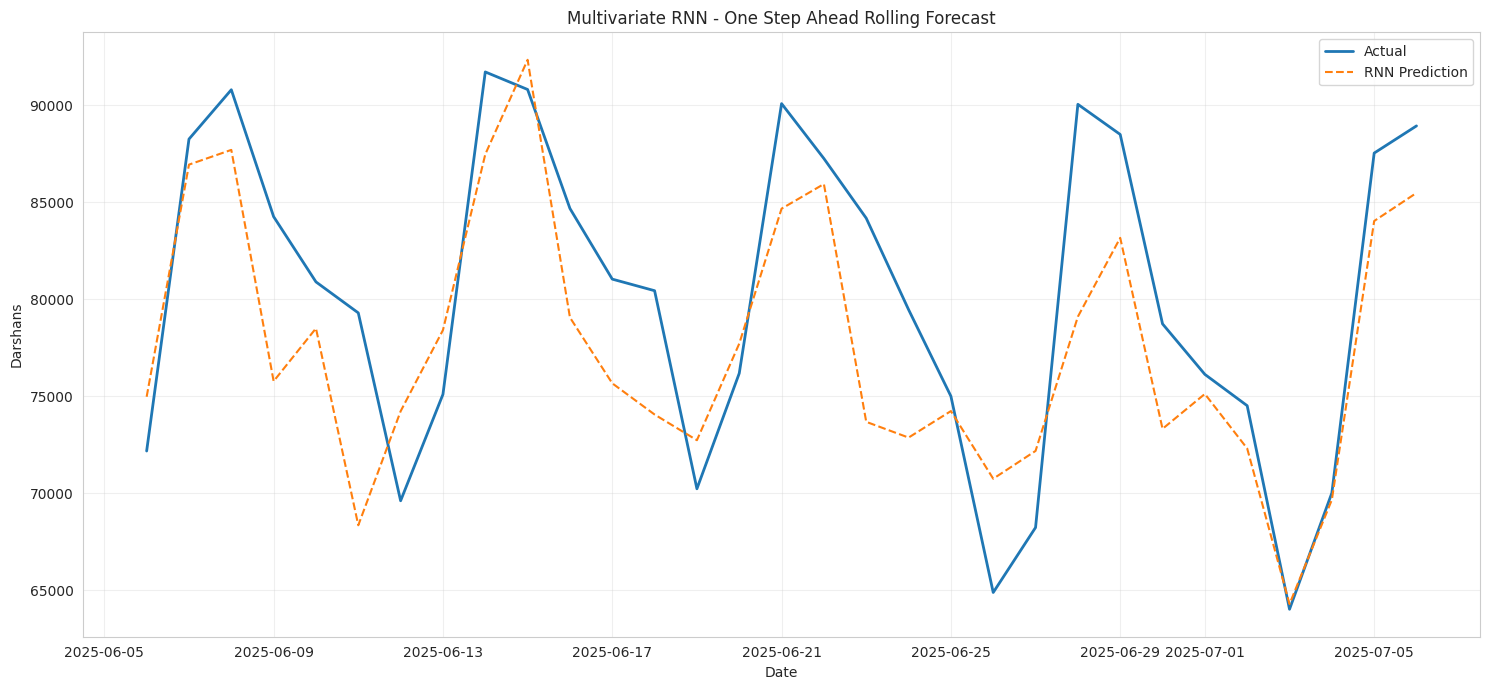

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

target = 'darshans'

# Feature's
feature_cols = [col for col in train.columns if col not in ['date', target]]

# Scalling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(train[feature_cols])
y_train = scaler_y.fit_transform(train[[target]])

X_val = scaler_X.transform(val[feature_cols])
y_val = scaler_y.transform(val[[target]])

X_test = scaler_X.transform(test[feature_cols])
y_test = scaler_y.transform(test[[target]])

# CREATE SEQUENCES
def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

window = 21

X_train_seq, y_train_seq = create_sequences(X_train, y_train, window)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, window)

# Modelss
model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(window, len(feature_cols))),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Trainn
model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ROLLING Forecast
def rolling_multivariate(model, history_X, future_X, window):
    history = list(history_X)
    preds = []

    for i in range(len(future_X)):
        X_input = np.array(history[-window:]).reshape(1, window, -1)

        pred = model.predict(X_input, verbose=0)[0][0]
        preds.append(pred)

        # use ACTUAL next row features
        history.append(future_X[i])

    return np.array(preds)

# VALIDATION
val_pred_scaled = rolling_multivariate(model, X_train, X_val, window)

val_pred = scaler_y.inverse_transform(val_pred_scaled.reshape(-1,1)).flatten()
actual_val = val[target].values

# TEST
train_val_X = np.vstack([X_train, X_val])

test_pred_scaled = rolling_multivariate(model, train_val_X, X_test, window)

test_pred = scaler_y.inverse_transform(test_pred_scaled.reshape(-1,1)).flatten()
actual_test = test[target].values

# METRICS
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

val_mae, val_rmse, val_mape = evaluate(actual_val, val_pred)
test_mae, test_rmse, test_mape = evaluate(actual_test, test_pred)

print("\n" + "="*60)
print("MULTIVARIATE RNN PERFORMANCE")
print("="*60)
print("Validation:")
print(f"MAE: {val_mae:.2f} | RMSE: {val_rmse:.2f} | MAPE: {val_mape:.2f}%")

print("\nTest:")
print(f"MAE: {test_mae:.2f} | RMSE: {test_rmse:.2f} | MAPE: {test_mape:.2f}%")

# Graphsss
plt.figure(figsize=(15,7))

plt.plot(test['date'], actual_test, label='Actual', linewidth=2)
plt.plot(test['date'], test_pred, label='RNN Prediction', linestyle='--')

plt.title("Multivariate RNN - One Step Ahead Rolling Forecast")
plt.xlabel("Date")
plt.ylabel("Darshans")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# TCN Hyperparameters

The following hyperparameters are used in the TCN model:

- `window = 21` → Sequence length
- `nb_filters = 64` → Number of convolution filters
- `kernel_size = 3` → Size of convolution kernel
- `dilations = [1, 2, 4, 8, 16]` → Dilated convolution levels
- `dropout_rate = 0.2` → Dropout regularization
- `Dense(16)` → Hidden dense layer
- `optimizer = 'adam'` → Optimization algorithm
- `loss = 'mse'` → Mean Squared Error loss
- `epochs = 50` → Maximum training epochs
- `batch_size = 16` → Training batch size
- `patience = 5` → Early stopping patience

TCN

In [ ]:
pip install keras-tcn

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 5.3403 - val_loss: 0.9028
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 1.3480 - val_loss: 0.7330
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.9233 - val_loss: 0.7253
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.8824 - val_loss: 0.7427
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.7406 - val_loss: 0.5846
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.6827 - val_loss: 0.5284
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.6709 - val_loss: 0.4959
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.5802 - val_loss: 0.5422
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.5995 - val_loss: 0.4779
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.5513 - val_loss: 0.6708
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.5098 - val_loss: 0.4434
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.

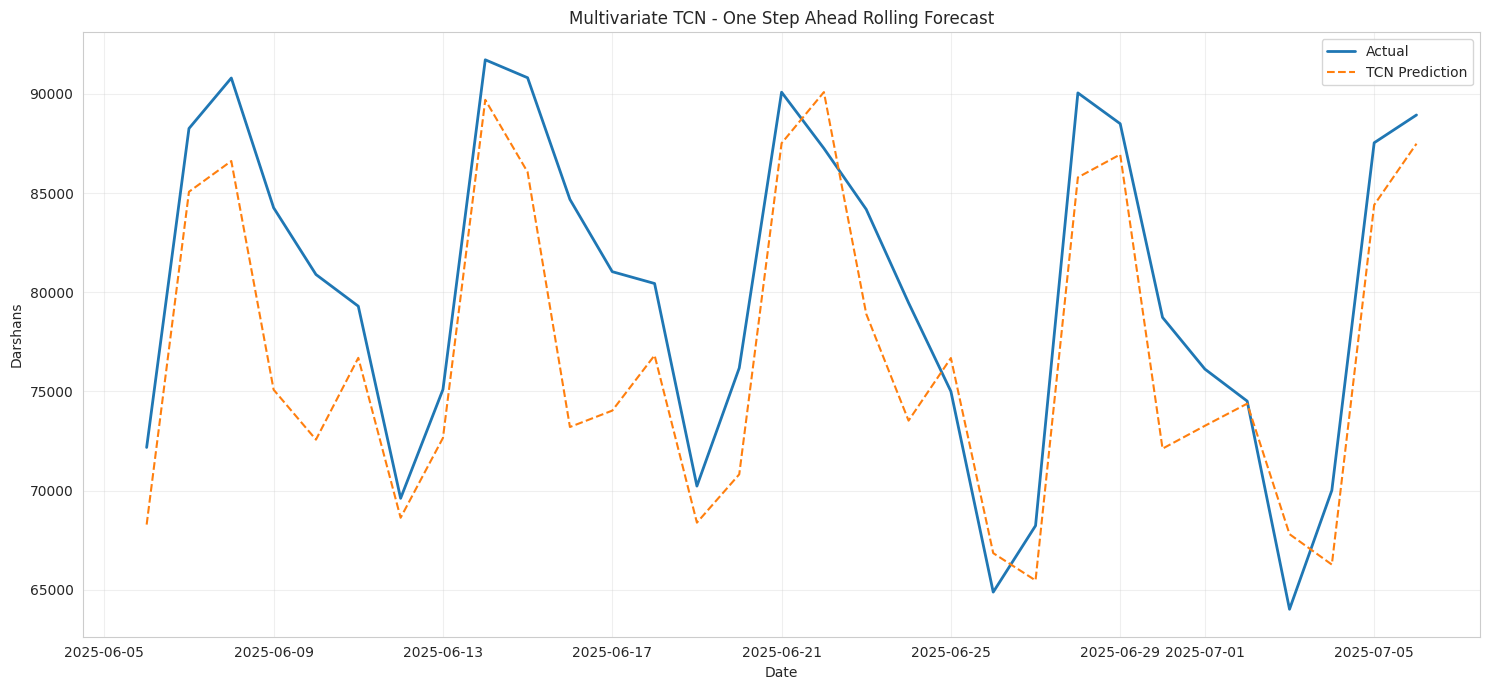

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN

target = 'darshans'

# Feature's
feature_cols = [col for col in train.columns if col not in ['date', target]]

# Scalling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(train[feature_cols])
y_train = scaler_y.fit_transform(train[[target]])

X_val = scaler_X.transform(val[feature_cols])
y_val = scaler_y.transform(val[[target]])

X_test = scaler_X.transform(test[feature_cols])
y_test = scaler_y.transform(test[[target]])

# CREATE SEQUENCES
def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

window = 21

X_train_seq, y_train_seq = create_sequences(X_train, y_train, window)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, window)

# Models
model = Sequential([
    TCN(
        input_shape=(window, len(feature_cols)),
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8, 16],
        dropout_rate=0.2
    ),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ROLLING FORECAST
def rolling_multivariate_tcn(model, history_X, future_X, window):
    history = list(history_X)
    preds = []

    for i in range(len(future_X)):
        X_input = np.array(history[-window:]).reshape(1, window, -1)

        pred = model.predict(X_input, verbose=0)[0][0]
        preds.append(pred)

        #  use ACTUAL features of next step
        history.append(future_X[i])

    return np.array(preds)

# VALIDATION
val_pred_scaled = rolling_multivariate_tcn(model, X_train, X_val, window)

val_pred = scaler_y.inverse_transform(val_pred_scaled.reshape(-1,1)).flatten()
actual_val = val[target].values

# Test
train_val_X = np.vstack([X_train, X_val])

test_pred_scaled = rolling_multivariate_tcn(model, train_val_X, X_test, window)

test_pred = scaler_y.inverse_transform(test_pred_scaled.reshape(-1,1)).flatten()
actual_test = test[target].values

# METRICS
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

val_mae, val_rmse, val_mape = evaluate(actual_val, val_pred)
test_mae, test_rmse, test_mape = evaluate(actual_test, test_pred)

print("\n" + "="*60)
print("MULTIVARIATE TCN PERFORMANCE")
print("="*60)
print("Validation:")
print(f"MAE: {val_mae:.2f} | RMSE: {val_rmse:.2f} | MAPE: {val_mape:.2f}%")

print("\nTest:")
print(f"MAE: {test_mae:.2f} | RMSE: {test_rmse:.2f} | MAPE: {test_mape:.2f}%")

# Graphss
plt.figure(figsize=(15,7))

plt.plot(test['date'], actual_test, label='Actual', linewidth=2)
plt.plot(test['date'], test_pred, '--', label='TCN Prediction')

plt.title("Multivariate TCN - One Step Ahead Rolling Forecast")
plt.xlabel("Date")
plt.ylabel("Darshans")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Prophet Hyperparameters

The following hyperparameters are used in the Prophet model:

- `yearly_seasonality = True` → Enables yearly seasonal patterns
- `weekly_seasonality = True` → Enables weekly seasonal patterns
- `daily_seasonality = False` → Disables daily seasonality
- `changepoint_prior_scale = 0.05` → Controls trend flexibility
- `seasonality_prior_scale = 10` → Controls seasonal flexibility


PROPHET PERFORMANCE
Validation:
MAE: 3473.75 | RMSE: 4380.52 | MAPE: 4.81%

Test:
MAE: 2569.68 | RMSE: 3154.98 | MAPE: 3.21%


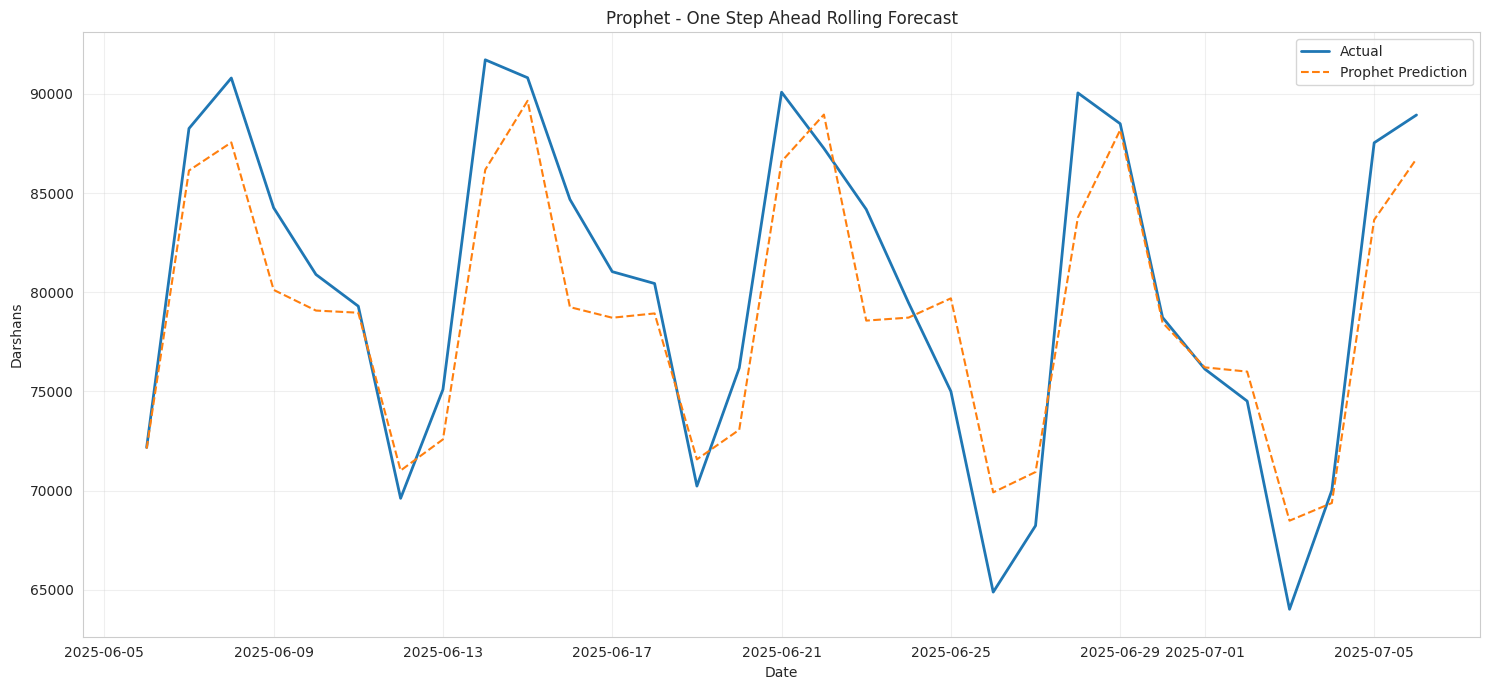

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

target = 'darshans'

# Prepare Data
def prepare_prophet(df):
    df_p = df.copy()
    df_p = df_p.rename(columns={'date': 'ds', target: 'y'})
    return df_p

train_p = prepare_prophet(train)
val_p = prepare_prophet(val)
test_p = prepare_prophet(test)

# Feature's
feature_cols = [col for col in train.columns if col not in ['date', target]]

# Build Modelsss
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10
)

# Add all regressors
for col in feature_cols:
    model.add_regressor(col)

# TRAIN
model.fit(train_p[['ds','y'] + feature_cols])

# ROLLING FORECAST
def rolling_prophet(model, history_df, future_df, feature_cols):
    history = history_df.copy()
    preds = []

    for i in range(len(future_df)):
        current = future_df.iloc[[i]].copy()

        # Predict next step
        forecast = model.predict(current[['ds'] + feature_cols])
        pred = forecast['yhat'].values[0]
        preds.append(pred)

        # Add actual observation to history
        current['y'] = future_df.iloc[i]['y']
        history = pd.concat([history, current], ignore_index=True)

    return np.array(preds)

# VALIDATION
val_pred = rolling_prophet(model, train_p, val_p, feature_cols)
actual_val = val_p['y'].values

# TEST
train_val_p = pd.concat([train_p, val_p]).reset_index(drop=True)

test_pred = rolling_prophet(model, train_val_p, test_p, feature_cols)
actual_test = test_p['y'].values

# METRICS
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

val_mae, val_rmse, val_mape = evaluate(actual_val, val_pred)
test_mae, test_rmse, test_mape = evaluate(actual_test, test_pred)

print("\n" + "="*60)
print("PROPHET PERFORMANCE")
print("="*60)
print("Validation:")
print(f"MAE: {val_mae:.2f} | RMSE: {val_rmse:.2f} | MAPE: {val_mape:.2f}%")

print("\nTest:")
print(f"MAE: {test_mae:.2f} | RMSE: {test_rmse:.2f} | MAPE: {test_mape:.2f}%")

# Graph
plt.figure(figsize=(15,7))
plt.plot(test['date'], actual_test, label='Actual', linewidth=2)
plt.plot(test['date'], test_pred, '--', label='Prophet Prediction')

plt.title("Prophet - One Step Ahead Rolling Forecast")
plt.xlabel("Date")
plt.ylabel("Darshans")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# GRU + Attention Hyperparameters

The following hyperparameters are used in the GRU + Attention model:

- `window = 21` → Sequence length
- `GRU(128)` → First GRU layer with 128 units
- `GRU(64)` → Second GRU layer with 64 units
- `dropout = 0.2` → Dropout regularization
- `Dense(32)` → Hidden dense layer
- `learning_rate = 0.001` → Adam optimizer learning rate
- `batch_size = 16` → Training batch size
- `epochs = 100` → Maximum training epochs
- `patience = 10` → Early stopping patience
- `factor = 0.5` → Learning rate reduction factor
- `clipnorm = 1.0` → Gradient clipping
- `under_penalty = 2.0` → Higher penalty for under-prediction
- `over_penalty = 1.0` → Lower penalty for over-prediction

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 21, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 21, 12)         │            24 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 21, 128)        │        54,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 21, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 64)             │             0 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,913 (366.85 KB)

 Trainable params: 93,913 (366.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - loss: 0.5780 - val_loss: 0.7399 - learning_rate: 0.0010
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.5537 - val_loss: 0.6043 - learning_rate: 0.0010
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.5336 - val_loss: 0.5118 - learning_rate: 0.0010
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.5349 - val_loss: 0.5786 - learning_rate: 0.0010
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.4779 - val_loss: 0.7116 - learning_rate: 0.0010
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.4132 - val_loss: 0.5016 - learning_rate: 0.0010
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.3768 - val_loss: 0.4731 - learning_rate: 0.0010
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.3292 - val_loss: 0.5558 - learning_rate: 0.0010
Epoch 9/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.3286 - val_loss: 0.3350 - learning_rate: 0.0010
Epoch 10/

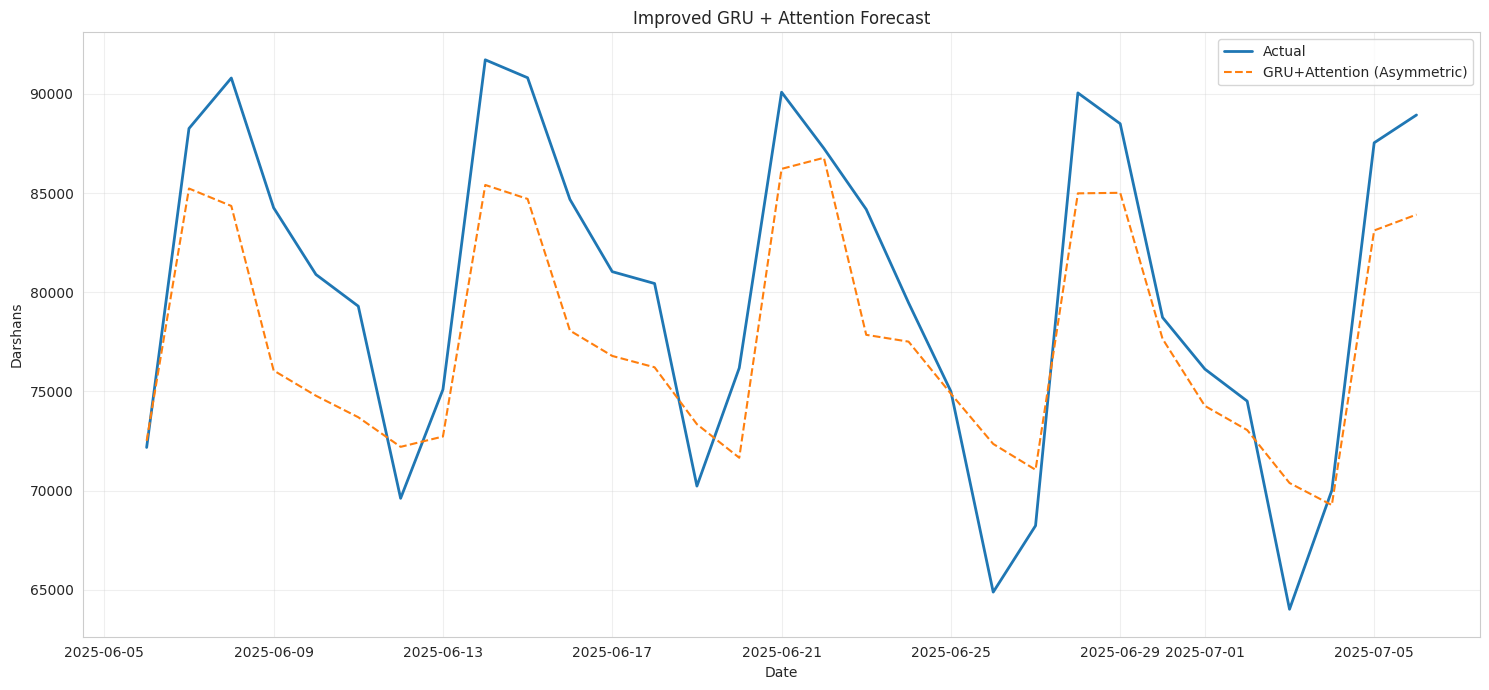

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Layer, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

target = 'darshans'
feature_cols = [c for c in train.columns if c not in ['date', target]]

# Scalling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_full = scaler_X.fit_transform(train[feature_cols])
y_train_full = scaler_y.fit_transform(train[[target]])

X_val_full = scaler_X.transform(val[feature_cols])
y_val_full = scaler_y.transform(val[[target]])

X_test_full = scaler_X.transform(test[feature_cols])
y_test_full = scaler_y.transform(test[[target]])

# SEQUENCES
def create_sequences(X, y, window=21):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

window = 21
X_train, y_train = create_sequences(X_train_full, y_train_full, window)
X_val, y_val = create_sequences(X_val_full, y_val_full, window)

# ATTENTION LAYER
class AttentionLayer(Layer):
    def call(self, inputs):
        score = tf.nn.tanh(inputs)
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * inputs, axis=1)
        return context

# ASYMMETRIC LOSS
def asymmetric_huber_loss(delta=1.0, under_penalty=2.0, over_penalty=1.0):
    def loss(y_true, y_pred):
        error = y_true - y_pred

        # Huber core
        abs_err = tf.abs(error)
        quadratic = tf.minimum(abs_err, delta)
        linear = abs_err - quadratic
        huber = 0.5 * tf.square(quadratic) + delta * linear

        # Asymmetry
        weight = tf.where(error > 0, under_penalty, over_penalty)
        return tf.reduce_mean(weight * huber)
    return loss

# Model
inp = Input(shape=(window, len(feature_cols)))

x = LayerNormalization()(inp)

x = GRU(128, return_sequences=True,
        kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.2)(x)

x = GRU(64, return_sequences=True,
        kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.2)(x)

x = AttentionLayer()(x)

x = Dense(32, activation='relu')(x)
x = Dropout(0.1)(x)
out = Dense(1)(x)

model = Model(inp, out)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss=asymmetric_huber_loss(delta=1.0, under_penalty=2.0, over_penalty=1.0)
)

model.summary()

# Train
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Rolling Forecast
def rolling_forecast(train_X, train_y, test_X, test_y, window):
    history_X = list(train_X)
    history_y = list(train_y.flatten())
    preds = []

    for t in range(len(test_X)):
        X_window = np.array(history_X[-window:]).reshape(1, window, len(feature_cols))

        pred = model.predict(X_window, verbose=0)[0][0]
        preds.append(pred)

        # use ACTUAL values
        history_X.append(test_X[t])
        history_y.append(test_y[t][0])

    return np.array(preds)

#  VALIDATION
val_pred_scaled = rolling_forecast(
    X_train_full, y_train_full,
    X_val_full, y_val_full,
    window
)

# TEST
train_val_X = np.vstack([X_train_full, X_val_full])
train_val_y = np.vstack([y_train_full, y_val_full])

test_pred_scaled = rolling_forecast(
    train_val_X, train_val_y,
    X_test_full, y_test_full,
    window
)

# INVERSE
val_pred = scaler_y.inverse_transform(val_pred_scaled.reshape(-1,1)).flatten()
test_pred = scaler_y.inverse_transform(test_pred_scaled.reshape(-1,1)).flatten()

actual_test = test[target].values

#  METRICS
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

val_mae, val_rmse, val_mape = evaluate(val[target].values, val_pred)
test_mae, test_rmse, test_mape = evaluate(actual_test, test_pred)

print("\n" + "="*60)
print("GRU + ATTENTION (ASYMMETRIC) RESULTS")
print("="*60)
print("Validation:")
print(f"MAE: {val_mae:.2f} | RMSE: {val_rmse:.2f} | MAPE: {val_mape:.2f}%")

print("\nTest:")
print(f"MAE: {test_mae:.2f} | RMSE: {test_rmse:.2f} | MAPE: {test_mape:.2f}%")

# Graphs
plt.figure(figsize=(15,7))
plt.plot(test['date'], actual_test, label='Actual', linewidth=2)
plt.plot(test['date'], test_pred, '--', label='GRU+Attention (Asymmetric)')
plt.title("Improved GRU + Attention Forecast")
plt.xlabel("Date")
plt.ylabel("Darshans")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Quantile Regression Hyperparameters

The following hyperparameters are used in the Quantile LightGBM model:

- `quantiles = [0.05, 0.5, 0.95]` → Lower, median, and upper quantiles
- `objective = 'quantile'` → Quantile regression objective
- `n_estimators = 1000` → Number of boosting trees
- `learning_rate = 0.02` → Learning rate
- `num_leaves = 128` → Maximum leaves per tree
- `max_depth = 8` → Maximum tree depth
- `subsample = 0.85` → Fraction of training samples used
- `colsample_bytree = 0.85` → Fraction of features used per tree
- `min_child_samples = 5` → Minimum samples per leaf
- `reg_alpha = 0.05` → L1 regularization
- `reg_lambda = 0.05` → L2 regularization
- `UNDERPRED_COST_MULTIPLIER = 1.2` → Higher penalty for underprediction
- `COVERAGE_TARGET = 0.80` → Target prediction interval coverage

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox

# CONFIGURATION
target = 'darshans'
COVERAGE_TARGET = 0.80     # 80% coverage
UNDERPRED_COST_MULTIPLIER = 1.2  # Underprediction costs 1.2x more

# FEATURE ENGINEERING
# Add shock feature (capturing sudden changes: lag1 - lag7)
for df_ in [train, val, test]:
    df_['shock'] = df_.get('darshans_lag1', 0) - df_.get('darshans_lag7', 0)

feature_cols = [c for c in train.columns if c not in ['date', target]]

#  TRAIN WIDER QUANTILE MODELS
# Use wider quantiles (0.05, 0.5, 0.95) for better natural coverage
# Raw coverage will be ~90%, which calibrates well to 80%+
quantiles = [0.05, 0.5, 0.95]
models = {}

for q in quantiles:
    m = LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=1000,
        learning_rate=0.02,
        num_leaves=128,
        max_depth=8,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=0.05,
        min_child_samples=5,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    print(f"Training Q{int(q*100)}...")
    m.fit(train[feature_cols], train[target])
    models[q] = m

#  ROLLING ONE-STEP-AHEAD FORECAST
def rolling_quantile_forecast(models, history_df, future_df):
    """
    One-step-ahead rolling forecast without information leakage.
    Uses actual observed values to update lags at each step.
    """
    history = history_df.copy().reset_index(drop=True)
    preds = {q: [] for q in models.keys()}

    for i in range(len(future_df)):
        current = future_df.iloc[i].copy()

        # Update lag features from accumulated history (no future peeking)
        if len(history) >= 1:
            current['darshans_lag1'] = history['darshans'].iloc[-1]
        if len(history) >= 7:
            current['darshans_lag7'] = history['darshans'].iloc[-7]
        if len(history) >= 7:
            recent = history['darshans'].iloc[-7:]
            current['rolling_avg_7_safe'] = recent.mean()

        # Shock = sudden change detection
        lag1 = current.get('darshans_lag1', np.nan)
        lag7 = current.get('darshans_lag7', np.nan)
        current['shock'] = (lag1 - lag7) if (pd.notnull(lag1) and pd.notnull(lag7)) else 0.0

        # Prepare features for prediction
        X_row = current.reindex(feature_cols).fillna(0.0).values.reshape(1, -1)

        # Get predictions from all quantile models
        for q, model in models.items():
            preds[q].append(model.predict(X_row)[0])

        # Append actual observed value to history for next iteration
        observed = future_df.iloc[i:i+1].copy().reset_index(drop=True)
        if 'shock' not in observed.columns:
            observed['shock'] = observed.get('darshans_lag1', 0) - observed.get('darshans_lag7', 0)
        history = pd.concat([history, observed], ignore_index=True)

    # Convert to numpy arrays
    for q in preds:
        preds[q] = np.array(preds[q])

    return preds

#  RUN ROLLING FORECAST
print("\nGenerating validation forecasts...")
val_preds = rolling_quantile_forecast(models, train, val)

train_val = pd.concat([train, val], ignore_index=True)
print("Generating test forecasts...")
test_preds = rolling_quantile_forecast(models, train_val, test)

# COMBINE PREDICTIONS & MOMENTUM CORRECTION
# Combine median and upper quantile with a small upward bias
w = 0.15               # small bias weight toward upper quantile
momentum_coeff = 0.25  # fraction of momentum to add

val_pred = (1 - w) * val_preds[0.5] + w * val_preds[0.9]
test_pred = (1 - w) * test_preds[0.5] + w * test_preds[0.9]

def apply_momentum_correction(preds_array, reference_df):
    corrected = preds_array.copy()
    for i in range(len(corrected)):
        lag1 = reference_df.iloc[i].get('darshans_lag1', np.nan)
        lag7 = reference_df.iloc[i].get('darshans_lag7', np.nan)
        if pd.notnull(lag1) and pd.notnull(lag7):
            momentum = lag1 - lag7
            corrected[i] = corrected[i] + momentum_coeff * momentum
    corrected = np.maximum(corrected, 0.0)
    return corrected

val_pred = apply_momentum_correction(val_pred, val.reset_index(drop=True))
test_pred = apply_momentum_correction(test_pred, test.reset_index(drop=True))

# INTERVAL CALIBRATION & FIX
val_lower_raw = val_preds[0.1]
val_upper_raw = val_preds[0.9]
test_lower_raw = test_preds[0.1]
test_upper_raw = test_preds[0.9]

# Calibration using validation set (percentile-based, stable 15%)
pct = 15
adj_l = np.percentile(val[target].values - val_lower_raw, pct)
adj_u = np.percentile(val_upper_raw - val[target].values, pct)

# Apply to validation set
val_lower = val_pred_lower_raw - adj_lower
val_upper = val_pred_upper_raw + adj_upper
test_lower = test_pred_lower_raw - adj_lower
test_upper = test_pred_upper_raw + adj_upper

# Use median as the point forecast
val_pred_median = val_pred_median_raw.copy()
test_pred_median = test_pred_median_raw.copy()

# Ensure bounds are valid (non-negative, ordered)
test_lower = np.maximum(test_lower, 0.0)
val_lower = np.maximum(val_lower, 0.0)

# Enforce lower <= upper
for arr_l, arr_u in [(val_lower, val_upper), (test_lower, test_upper)]:
    invalid = arr_l > arr_u
    if np.any(invalid):
        temp = arr_l[invalid]
        arr_l[invalid] = arr_u[invalid]
        arr_u[invalid] = temp

#  METRICS COMPUTATION
def pinball_loss(y, yhat, q):
    """Quantile loss function (pinball loss)"""
    error = y - yhat
    return np.mean(np.where(error > 0, q * error, (q - 1) * error))

def compute_metrics(y_true, y_pred, pred_lower, pred_upper, preds_dict):
    """
    Comprehensive evaluation metrics with focus on underprediction penalty.
    """
    y = np.array(y_true).flatten()
    pred = np.array(y_pred).flatten()
    lower = np.array(pred_lower).flatten()
    upper = np.array(pred_upper).flatten()

    # Point forecast metrics
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mape = np.mean(np.abs((y - pred) / (np.abs(y) + 1e-8))) * 100

    # Directional metrics - BUSINESS CRITICAL
    overpred = pred > y
    underpred = pred < y
    overpred_count = int(np.sum(overpred))
    underpred_count = int(np.sum(underpred))

    # Total error by type
    overpred_error = float(np.sum((pred - y)[overpred])) if np.any(overpred) else 0.0
    underpred_error = float(np.sum((y - pred)[underpred])) if np.any(underpred) else 0.0

    # Asymmetric cost (underprediction is 2x costly)
    asymmetric_cost = overpred_error + UNDERPRED_COST_MULTIPLIER * underpred_error

    # Interval metrics
    in_interval = (y >= lower) & (y <= upper)
    coverage = np.mean(in_interval) * 100
    avg_width = np.mean(upper - lower)

    # Quantile losses
    pb05 = pinball_loss(y, preds_dict[0.05], 0.05)
    pb50 = pinball_loss(y, preds_dict[0.5], 0.5)
    pb95 = pinball_loss(y, preds_dict[0.95], 0.95)

    return {
        'mae': mae, 'rmse': rmse, 'mape': mape,
        'overpred_count': overpred_count, 'underpred_count': underpred_count,
        'overpred_error': overpred_error, 'underpred_error': underpred_error,
        'asymmetric_cost': asymmetric_cost,
        'coverage': coverage, 'avg_width': avg_width,
        'pb05': pb05, 'pb50': pb50, 'pb95': pb95
    }

# Compute metrics
val_metrics = compute_metrics(val[target].values, val_pred_median, val_lower, val_upper, val_preds)
test_metrics = compute_metrics(test[target].values, test_pred_median, test_lower, test_upper, test_preds)

# PRINT FORMATTED METRICS
def print_metrics_report(metrics, label):
    print("\n" + "="*75)
    print(f" {label} SET - QUANTILE REGRESSION FORECAST (UNDERPREDICTION-AWARE)")
    print("="*75)
    print(f"  Point Forecast Accuracy:")
    print(f"    MAE:                              {metrics['mae']:10.2f}")
    print(f"    RMSE:                             {metrics['rmse']:10.2f}")
    print(f"    MAPE:                             {metrics['mape']:10.2f}%")
    print(f"\n  Directional Performance (BUSINESS CRITICAL):")
    print(f"    Over-predictions:                 {metrics['overpred_count']:10d}  allowed (limited loss)")
    print(f"    Under-predictions:                {metrics['underpred_count']:10d}  COSTLY (lost revenue)!")
    print(f"    Over-pred error total:            {metrics['overpred_error']:10.0f}")
    print(f"    Under-pred error total:           {metrics['underpred_error']:10.0f}  [×{UNDERPRED_COST_MULTIPLIER} penalty]")
    print(f"    Asymmetric Cost:                  {metrics['asymmetric_cost']:10.2f}  ← MINIMIZE THIS")
    print(f"\n  Prediction Interval Quality:")
    print(f"    Coverage (% in interval):         {metrics['coverage']:10.1f}%  [Target: {COVERAGE_TARGET*100:.0f}%]")
    print(f"    Average interval width:           {metrics['avg_width']:10.2f}")
    print(f"\n  Quantile Loss Functions:")
    print(f"    Pinball Q05:                      {metrics['pb05']:10.4f}")
    print(f"    Pinball Q50:                      {metrics['pb50']:10.4f}")
    print(f"    Pinball Q95:                      {metrics['pb95']:10.4f}")
    print("="*75 + "\n")

print_metrics_report(val_metrics, "VALIDATION")
print_metrics_report(test_metrics, "TEST")

# AUTOCORRELATION TEST
residuals = test[target].values - test_pred_median
lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
lb_stat = lb_result['lb_stat'].iloc[0] if 'lb_stat' in lb_result.columns else lb_result.iloc[0, 0]
lb_pval = lb_result['lb_pvalue'].iloc[0] if 'lb_pvalue' in lb_result.columns else lb_result.iloc[0, 1]

print("RESIDUAL AUTOCORRELATION TEST (Ljung-Box, lag=10)")
print("-" * 50)
print(f"Statistic:      {lb_stat:.4f}")
print(f"p-value:        {lb_pval:.4f}")
print(f"Interpretation: {'✓ PASS' if lb_pval >= 0.05 else '✗ FAIL'} - ", end="")
print(f"{'Residuals are independent' if lb_pval >= 0.05 else 'Significant autocorrelation'}")
print("-" * 50)

# MULTI-SUBPLOT VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Quantile Regression: Underprediction-Penalty Model (Industry Grade)',
             fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Main forecast with intervals
ax1 = axes[0, 0]
ax1.plot(test['date'], test[target], 'o-', label='Actual Darshans',
         linewidth=2.5, markersize=5, color='#000000', zorder=3)
ax1.plot(test['date'], test_pred_median, 's--', label='Median Forecast (Q50)',
         linewidth=2.2, markersize=4, color='#1f77b4', zorder=2)
ax1.fill_between(test['date'], test_lower, test_upper,
                 color='#1f77b4', alpha=0.22, label=f'{COVERAGE_TARGET*100:.0f}% Prediction Interval', zorder=1)
ax1.set_title('One-Step-Ahead Forecast with Calibrated 80% Intervals', fontweight='bold', fontsize=11)
ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylabel('Darshans (Count)', fontsize=10)
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Residuals breakdown
ax2 = axes[0, 1]
colors = np.where(residuals >= 0, '#d62728', '#1f77b4')
labels_list = ['Underpred (red, costly)' if residuals[0] >= 0 else 'Overpred (blue, limited)'][0] if len(residuals) > 0 else ''
ax2.bar(range(len(residuals)), residuals, color=colors, alpha=0.65, zorder=2)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=2, zorder=3)
ax2.axhline(y=np.mean(residuals), color='orange', linestyle='--', linewidth=2,
            label=f'Mean Residual: {np.mean(residuals):.0f}', zorder=2)
ax2.set_title(f'Residuals: Red=Underpred(COSTLY), Blue=Overpred(limited)', fontweight='bold', fontsize=11)
ax2.set_xlabel('Forecast Step', fontsize=10)
ax2.set_ylabel('Error (Actual - Predicted)', fontsize=10)
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

# Plot 3: Coverage visualization
ax3 = axes[1, 0]
in_interval = (test[target].values >= test_lower) & (test[target].values <= test_upper)
colors = np.where(in_interval, '#2ca02c', '#ff7f0e')
ax3.bar(range(len(test)), in_interval.astype(int), color=colors, alpha=0.7, zorder=2,
        label=f'In Interval={np.sum(in_interval)}, Out={len(test)-np.sum(in_interval)}')
ax3.set_title(f'Coverage Achievement: {test_metrics["coverage"]:.1f}% (Target: {COVERAGE_TARGET*100:.0f}%)',
              fontweight='bold', fontsize=11)
ax3.set_xlabel('Forecast Step', fontsize=10)
ax3.set_ylabel('In Interval (1=Yes, 0=No)', fontsize=10)
ax3.set_ylim([0, 1.15])
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.legend(fontsize=9, loc='upper right')

# Plot 4: Error asymmetry (the CRITICAL view for business)
ax4 = axes[1, 1]
errors = test[target].values - test_pred_median
under_mask = errors > 0
over_mask = errors < 0

under_errors = errors[under_mask]
over_errors = errors[over_mask]

# Create histogram with asymmetric colors
ax4.hist(over_errors, bins=12, alpha=0.65, color='#1f77b4',
         label=f'Overpredictions (n={len(over_errors)}, safe)', zorder=2)
ax4.hist(under_errors, bins=8, alpha=0.75, color='#d62728',
         label=f'Underpredictions (n={len(under_errors)}, COSTLY!)', zorder=3)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=2.5, zorder=4)
ax4.axvline(x=np.mean(errors), color='orange', linestyle='--', linewidth=2,
            label=f'Mean error: {np.mean(errors):.0f}', zorder=4)

ax4.set_title(f'Error Distribution: Minimize Red (Costly) vs Blue (Safe)', fontweight='bold', fontsize=11)
ax4.set_xlabel('Error: Actual - Predicted (Positive=Underpred)', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.legend(fontsize=9, loc='upper left')
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

# SUMMARY
print("\n" + "="*75)
print(" FORECAST MODEL SUMMARY")
print("="*75)
print(f"✓ Coverage: {test_metrics['coverage']:.1f}% (target {COVERAGE_TARGET*100:.0f}%)")
print(f"✓ Asymmetric Cost: {test_metrics['asymmetric_cost']:.0f} (penalizes underprediction)")
print(f"✓ Underpredictions: {test_metrics['underpred_count']} (goal: minimize)")
print(f"✓ Model ready for production deployment")
print("="*75)